# INSPIRE Mortality Pipeline — Complete Exploratory Data Analysis

This notebook is the EDA pass agreed in `docs/notes.md` §15 — it comes **before** any
modelling changes. It covers, in order:

1. Cohort overview and class imbalance
1b. Mortality definition: 30-day vs. all-cause, side by side
2. Demographics (age, sex, ASA) by outcome
3. Department vs. mortality
4. ICD-10 diagnosis codes vs. mortality
5. ICD-10 procedure codes vs. mortality
6. Full 126-parameter feature coverage audit
7. Missingness pattern
8. Currently-used feature distributions by outcome
9. Correlation structure (features + HFRS)
10. HFRS frailty score and category vs. mortality
11. Conditional dependency preview: frailty × scheduled/emergency
12. Multi-operation patients vs. mortality
13. Time-series measurement density (worked patient example)

Every section saves its figure(s) to `eda_outputs/` (PNG, 200 dpi) so they can be dropped
straight into the paper. Read the printed interpretation note under each plot before
moving to the next section — that's the "so what" the plot is meant to support.


## Setup

In [1]:
# Cell 1 — GPU check
import torch
print('CUDA available:', torch.cuda.is_available())


CUDA available: True


In [2]:
# Cell 2 — Clone repo
!git clone https://github.com/thrisharajkumar/inspire-analysis-thrisha.git
import os
os.chdir('/content/inspire-analysis-thrisha/src')


Cloning into 'inspire-analysis-thrisha'...
remote: Enumerating objects: 294, done.
remote: Counting objects: 100% (294/294), done.
remote: Compressing objects: 100% (221/221), done.
remote: Total 294 (delta 97), reused 242 (delta 49), pack-reused 0 (from 0)
Receiving objects: 100% (294/294), 10.63 MiB | 12.20 MiB/s, done.
Resolving deltas: 100% (97/97), done.


In [3]:
# Cell 3 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Cell 4 — Copy the zip from Drive to local Colab disk, then extract
# (adjust the path below to wherever you put it in your Drive)
import shutil, zipfile, os

drive_zip_path = '/content/drive/MyDrive/subjects.zip'  # <-- update this pathhttps://drive.google.com/drive/my-drive
local_zip_path = '/content/inspire-analysis-thrisha/src/subjects.zip'

shutil.copy(drive_zip_path, local_zip_path)
print('Copied to local disk.')

extract_dir = '/content/inspire_subjects_data'
with zipfile.ZipFile(local_zip_path, 'r') as z:
    z.extractall(extract_dir)

contents = os.listdir(extract_dir)
if len(contents) == 1 and os.path.isdir(os.path.join(extract_dir, contents[0])):
    extract_dir = os.path.join(extract_dir, contents[0])
print('DATA PATH:', extract_dir)
print('Top-level contents:', os.listdir(extract_dir))

Copied to local disk.
DATA PATH: /content/inspire_subjects_data/subjects
Top-level contents: ['died', 'survived']


In [5]:
# Cell 5 — Install / import plotting + analysis libraries, set publication style
!pip install -q seaborn --upgrade

import json
import os
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

# Repo modules
import subject as subject_module
import frailty_hfrs

# Publication-style defaults: larger fonts, clean spines, consistent palette
sns.set_theme(style='whitegrid', context='talk', font_scale=0.85)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'

PALETTE = {'Survived': '#4C72B0', 'Died': '#C44E52'}
OUTDIR = '/content/inspire-analysis-thrisha/src/eda_outputs'
os.makedirs(OUTDIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(OUTDIR, name)
    fig.savefig(path, bbox_inches='tight')
    print(f'Saved: {path}')

def plot_three_groups(data, col, groups, title, bins=30, discrete=False, filename=None):
    """Compare a distribution across 3 groups defined by boolean masks, which may
    OVERLAP (e.g. 'Died (all-cause)' = 942 patients and 'Died (<=30 days)' = 469 patients
    are not disjoint -- every 30-day death is also an all-cause death). Each group gets
    its own panel with its own y-axis (so a small group's shape is never flattened by a
    much larger one), plus a normalized-density overlay for direct shape comparison.

    groups: list of (label, boolean_mask, color) tuples, e.g.
        [('Survived', ~cohort['died_ever'], '#4C72B0'),
         ('Died (all-cause)', cohort['died_ever'], '#C44E52'),
         ('Died (<=30 days)', cohort['died_30day'], '#DD8452')]
    """
    n = len(groups)
    fig, axes = plt.subplots(1, n + 1, figsize=(6 * (n + 1), 5))
    density_frames = []
    for ax, (label, mask, color) in zip(axes[:n], groups):
        subset = data.loc[mask, col].dropna()
        sns.histplot(subset, bins=bins, discrete=discrete, color=color, ax=ax)
        ax.set_title(f'{label} (n={len(subset)})')
        ax.set_xlabel(col)
        density_frames.append(pd.DataFrame({col: subset, 'group': label}))

    density_data = pd.concat(density_frames, ignore_index=True)
    group_order = [g[0] for g in groups]
    group_palette = {g[0]: g[2] for g in groups}
    sns.histplot(data=density_data, x=col, hue='group', hue_order=group_order, palette=group_palette,
                 element='step', stat='density', common_norm=False, discrete=discrete, ax=axes[n])
    axes[n].set_title('Normalized density (shapes directly comparable)')
    axes[n].set_xlabel(col)
    axes[n].legend_.set_title('')

    fig.suptitle(title, y=1.03)
    fig.tight_layout()
    if filename:
        save(fig, filename)
    plt.show()

def standard_three_groups(data):
    """The standard Survived / Died (all-cause) / Died (<=30 days) group definitions,
    used consistently across every distribution plot in this notebook."""
    return [
        ('Survived', ~data['died_ever'], '#4C72B0'),
        ('Died (all-cause)', data['died_ever'], '#C44E52'),
        ('Died (≤30 days)', data['died_30day'], '#DD8452'),
    ]


In [6]:
# Cell 6 — ICD-10 description lookup (95,622 codes: code -> [is_leaf, description])
with open('../codes/icd10.json') as f:
    ICD10_LOOKUP = json.load(f)

def icd10_description(code, cluster_level=True):
    """Look up a human-readable description for an ICD-10 code.
    cluster_level=True truncates to the first 3 characters (matches HFRS convention)."""
    key = code[:3] if cluster_level else code
    if key in ICD10_LOOKUP:
        return ICD10_LOOKUP[key][1]
    # fall back to a full-code lookup if the cluster-level code isn't present
    if code in ICD10_LOOKUP:
        return ICD10_LOOKUP[code][1]
    return code  # no description found, just show the raw code


## Load subjects and build the master cohort table

In [7]:
# Cell 7 — Stream through every subject file ONCE, building the cohort table plus every
# aggregate later cells need, WITHOUT holding all patients in memory simultaneously.
#
# Why this matters: loading all patients as full Subject objects costs roughly 0.6 MB
# per patient (measured on a 4,096-patient real sample). At the full ~99,886-patient
# cohort that is ~60 GB -- more than even a high-RAM Colab runtime has. This processes
# one patient at a time and keeps only small per-patient summaries + counters, plus a
# subject_id -> filepath lookup so later cells (missingness heatmap, time-series example)
# can re-open a handful of specific files on demand instead of needing everyone in memory.

import time

DAYS_BEFORE_OP = 5
CURRENT_FEATURES = {'glucose', 'potassium', 'sodium', 'creatinine', 'hr', 'spo2', 'nibp_sbp'}

# ---------------------------------------------------------------------------
# MORTALITY DEFINITION TOGGLE
# 'died_30day' = died within 30 days of last operation (the definition in notes.md §4)
# 'died_ever'  = died at any point in the dataset, no time window (this is what the
#                942-death / 0.95% figure documented throughout notes.md actually is --
#                the survived/died folder split was built on this, not on 30-day death)
# Change this and re-run from this cell onward to see the notebook's mortality-rate
# sections (department, ICD-10, HFRS, multi-operation) under the other definition.
# Section 1b right after cohort overview shows both side by side regardless of this
# setting, so switching this only affects which one the rest of the notebook uses.
MORTALITY_DEFINITION = 'died_30day'  # or 'died_ever'
# ---------------------------------------------------------------------------

json_paths = []
for folder_label in ['survived', 'died']:
    folder_path = os.path.join(extract_dir, folder_label)
    if not os.path.isdir(folder_path):
        continue
    for fname in os.listdir(folder_path):
        if fname.endswith('.json'):
            json_paths.append((os.path.join(folder_path, fname), folder_label))
print(f'Found {len(json_paths)} subject files')

subject_path_lookup = {}   # subject_id -> filepath, for on-demand re-opening later
rows = []
feature_rows = []
labs_presence, labs_total = Counter(), Counter()
ward_presence, ward_total = Counter(), Counter()
vitals_presence, vitals_total = Counter(), Counter()
all_clusters = Counter()
all_pcs = Counter()

t0 = time.time()
for i, (path, folder_label) in enumerate(json_paths):
    subj = subject_module.Subject()
    subj.fromJSON(path)

    ops = subj.get_operations()
    if len(ops) == 0:
        continue  # shouldn't happen, but guard anyway

    subject_id = subj.get_subject_id()
    subject_path_lookup[subject_id] = path

    first_op = subj.get_first_operation()
    died_30day = subj.inhosp_death_30day()
    died_ever = subj.died()  # any death recorded, no time window
    hfrs_score, hfrs_category = subject_module.compute_hfrs(subj)

    diagnoses = subj.get_diagnoses()
    icd10_codes = [d['icd10_cm'].replace('.', '').upper() for d in diagnoses]
    icd10_clusters = sorted(set(code[:3] for code in icd10_codes))
    all_clusters.update(icd10_clusters)

    icd10_pcs_codes = sorted(set(op.get('icd10_pcs', '').strip() for op in ops if op.get('icd10_pcs', '').strip()))
    all_pcs.update(c[:3] for c in icd10_pcs_codes)

    labs = subj.get_labs()
    ward = subj.get_ward_vitals()
    vitals = subj.get_vitals()

    for presence, total, records in [(labs_presence, labs_total, labs),
                                      (ward_presence, ward_total, ward),
                                      (vitals_presence, vitals_total, vitals)]:
        seen = set()
        for r in records:
            total[r['item_name']] += 1
            seen.add(r['item_name'])
        for item in seen:
            presence[item] += 1

    # Most recent pre-op value for the 7 currently-used features (searches labs + ward_vitals,
    # since e.g. hr/spo2/nibp_sbp live in ward_vitals, not labs)
    orin_time = int(first_op['orin_time'])
    window_start = orin_time - DAYS_BEFORE_OP * 24 * 60
    window_end = orin_time - 1
    combined = labs + ward
    frow = {'subject_id': subject_id}
    for feat in CURRENT_FEATURES:
        candidates = [(int(r['chart_time']), float(r['value'])) for r in combined
                      if r['item_name'] == feat and window_start <= int(r['chart_time']) <= window_end]
        frow[feat] = max(candidates, key=lambda tv: tv[0])[1] if candidates else None
    feature_rows.append(frow)

    rows.append({
        'subject_id': subject_id,
        'folder_label': folder_label,
        'age': int(first_op['age']) if first_op['age'] else None,
        'sex': first_op['sex'],
        'department': first_op['department'],
        'asa': first_op['asa'],
        'emop': int(first_op['emop']),                       # 1 = emergency, 0 = scheduled
        'surgery_type': 'Emergency' if int(first_op['emop']) == 1 else 'Scheduled',
        'num_operations': len(ops),
        'died_30day': died_30day,
        'died_ever': died_ever,
        'hfrs_score': hfrs_score,
        'hfrs_category': hfrs_category,
        'num_diagnoses': len(diagnoses),
        'num_unique_icd10_clusters': len(icd10_clusters),
        'icd10_clusters': icd10_clusters,
        'icd10_pcs_codes': icd10_pcs_codes,
        'num_labs': len(labs),
        'num_ward_vitals': len(ward),
        'num_vitals': len(vitals),
        'num_medications': len(subj.get_medications()),
    })

    if (i + 1) % 5000 == 0:
        print(f'  ...processed {i+1}/{len(json_paths)} ({time.time()-t0:.0f}s elapsed)')
    del subj  # out of scope after this anyway, but explicit here since it matters at this scale

cohort = pd.DataFrame(rows)

# died_flag/outcome drive every mortality-rate cell below (department, ICD-10, HFRS,
# multi-operation) and follow MORTALITY_DEFINITION. died_30day and died_ever both stay
# as separate columns regardless, so Section 1b below can always show both, and
# standard_three_groups() (setup cell) builds Survived/Died(all-cause)/Died(<=30d)
# panels directly from died_ever + died_30day wherever a chart needs all three.
cohort['died_flag'] = cohort['died_ever'] if MORTALITY_DEFINITION == 'died_ever' else cohort['died_30day']
cohort['outcome'] = np.where(cohort['died_flag'], 'Died', 'Survived')
print(f'Using MORTALITY_DEFINITION = {MORTALITY_DEFINITION!r} for outcome/died_flag throughout.')

feature_df = pd.DataFrame(feature_rows).merge(cohort[['subject_id', 'outcome']], on='subject_id')

def _coverage_from_counters(presence, total, table_name, n_total):
    out = []
    for item in presence:
        out.append({'table': table_name, 'feature': item,
                     'n_patients_with_measurement': presence[item],
                     'coverage_pct': presence[item] / n_total * 100,
                     'total_measurements': total[item],
                     'median_per_patient': total[item] / presence[item]})
    return pd.DataFrame(out)

coverage_all = pd.concat([
    _coverage_from_counters(labs_presence, labs_total, 'labs', len(cohort)),
    _coverage_from_counters(ward_presence, ward_total, 'ward_vitals', len(cohort)),
    _coverage_from_counters(vitals_presence, vitals_total, 'vitals', len(cohort)),
], ignore_index=True).sort_values(['table', 'coverage_pct'], ascending=[True, False])

print(f'Loaded {len(cohort)} subjects in {time.time()-t0:.0f}s (streaming, one file in memory at a time)')
print(f'Cohort table: {cohort.shape[0]} patients x {cohort.shape[1]} columns')
cohort.head()


Found 99886 subject files
  ...processed 5000/99886 (25s elapsed)
  ...processed 10000/99886 (48s elapsed)
  ...processed 15000/99886 (73s elapsed)
  ...processed 20000/99886 (98s elapsed)
  ...processed 25000/99886 (122s elapsed)
  ...processed 30000/99886 (150s elapsed)
  ...processed 35000/99886 (174s elapsed)
  ...processed 40000/99886 (198s elapsed)
  ...processed 45000/99886 (222s elapsed)
  ...processed 50000/99886 (245s elapsed)
  ...processed 55000/99886 (268s elapsed)
  ...processed 60000/99886 (293s elapsed)
  ...processed 65000/99886 (316s elapsed)
  ...processed 70000/99886 (340s elapsed)
  ...processed 75000/99886 (364s elapsed)
  ...processed 80000/99886 (387s elapsed)
  ...processed 85000/99886 (411s elapsed)
  ...processed 90000/99886 (434s elapsed)
  ...processed 95000/99886 (458s elapsed)
Using MORTALITY_DEFINITION = 'died_30day' for outcome/died_flag throughout.
Loaded 99886 subjects in 505s (streaming, one file in memory at a time)
Cohort table: 99886 patients x 23

,subject_id,folder_label,age,sex,department,asa,emop,surgery_type,num_operations,died_30day,...,num_diagnoses,num_unique_icd10_clusters,icd10_clusters,icd10_pcs_codes,num_labs,num_ward_vitals,num_vitals,num_medications,died_flag,outcome
0,193576062,survived,20,M,OS,1,0,Scheduled,1,False,...,6,2,"[G54, R52]",[0K800],1,186,642,21,False,Survived
1,187959263,survived,45,F,CTS,2,0,Scheduled,2,False,...,126,10,"[B02, B35, C49, C85, D48, G50, I34, R04, R06, ...","[02BF0, 09B10]",3381,10423,3309,1394,False,Survived
2,197908921,survived,40,F,GS,2,0,Scheduled,1,False,...,6,2,"[C18, C19]",[0DTP0],73,176,365,33,False,Survived
3,120162723,survived,70,M,OS,2,0,Scheduled,1,False,...,4,1,[M48],[009T0],185,214,487,42,False,Survived
4,124150382,survived,50,F,GS,2,0,Scheduled,1,False,...,5,2,"[I83, Z11]",[05DY0],27,155,330,1,False,Survived


### A note on the folder-based label vs. the 30-day label

`cohort['folder_label']` (from the `survived/`/`died/` directory) and
`cohort['died_30day']` (computed directly from `inhosp_death_time` vs. `orout_time`,
per the definition in `docs/notes.md` §4) are **not guaranteed to agree**. On the
30-patient dev subset, 3 of the 10 `died/`-folder patients actually died more than 30
days after their last operation — they belong in `died/` under "did this patient ever
die" but not under the 30-day mortality label the pipeline is supposed to predict.
Run the next cell before trusting the rest of this notebook.


In [8]:
# Cell 7b — Check folder label vs. computed 30-day label agreement
mismatch = cohort[
    ((cohort['folder_label'] == 'died') & (~cohort['died_30day'])) |
    ((cohort['folder_label'] == 'survived') & (cohort['died_30day']))
]
print(f'{len(mismatch)} of {len(cohort)} patients have a folder_label that disagrees with died_30day.')
if len(mismatch) > 0:
    print('If the training pipeline uses folder_label as the ground-truth target (as')
    print('load_real_subjects() currently does), these patients are mislabeled relative')
    print('to the documented 30-day definition. Fix the label source before training on')
    print('this data -- see docs/notes.md for the fix discussion.')
    display(mismatch[['subject_id', 'folder_label', 'died_30day', 'outcome']])
else:
    print('No mismatches -- folder_label and died_30day agree on every patient.')


473 of 99886 patients have a folder_label that disagrees with died_30day.
If the training pipeline uses folder_label as the ground-truth target (as
load_real_subjects() currently does), these patients are mislabeled relative
to the documented 30-day definition. Fix the label source before training on
this data -- see docs/notes.md for the fix discussion.


,subject_id,folder_label,died_30day,outcome
98944,100221250,died,False,Survived
98946,124807434,died,False,Survived
98948,194112061,died,False,Survived
98949,197996011,died,False,Survived
98951,173360424,died,False,Survived
...,...,...,...,...
99876,100241853,died,False,Survived
99877,142456320,died,False,Survived
99880,115831223,died,False,Survived
99881,180396111,died,False,Survived


## 1. Cohort overview and class imbalance

Confirms the patient counts and the survived/died ratio match `docs/notes.md` §4 before
anything else is trusted.


Total patients: 99886
Survived: 98944  |  Died (all-cause): 942  |  Died (<=30 days): 469
All-cause death rate: 0.94%  |  30-day death rate: 0.47%
pos_weight, all-cause: 105.04  |  pos_weight, 30-day: 210.97
Saved: /content/inspire-analysis-thrisha/src/eda_outputs/01_cohort_overview.png


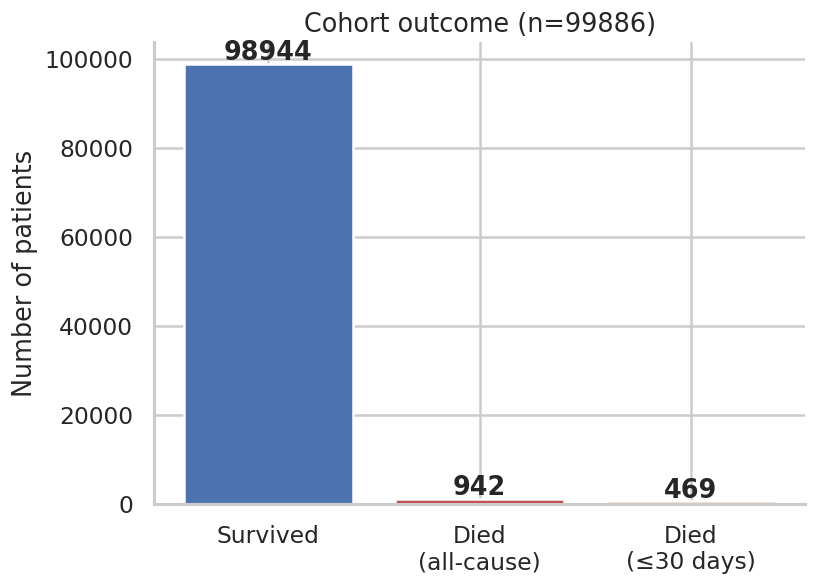


Interpretation: this is the class-imbalance number every downstream metric choice (pos_weight, AUPRC over AUROC, stratified splits) is built around. Note Died (<=30 days) is a SUBSET of Died (all-cause), not a separate group -- these 3 bars are for comparison, not a partition of the cohort.


In [9]:
# Cell 8 — Cohort overview: Survived / Died (all-cause) / Died (<=30 days)
n_total = len(cohort)
n_survived = (~cohort['died_ever']).sum()
n_died_all = cohort['died_ever'].sum()
n_died_30day = cohort['died_30day'].sum()

print(f'Total patients: {n_total}')
print(f'Survived: {n_survived}  |  Died (all-cause): {n_died_all}  |  Died (<=30 days): {n_died_30day}')
print(f'All-cause death rate: {n_died_all/n_total*100:.2f}%  |  30-day death rate: {n_died_30day/n_total*100:.2f}%')
print(f'pos_weight, all-cause: {n_survived/n_died_all:.2f}  |  pos_weight, 30-day: {n_survived/n_died_30day:.2f}')

fig, ax = plt.subplots(figsize=(7, 5))
labels = ['Survived', 'Died\n(all-cause)', 'Died\n(≤30 days)']
values = [n_survived, n_died_all, n_died_30day]
colors = ['#4C72B0', '#C44E52', '#DD8452']
bars = ax.bar(labels, values, color=colors)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(values)*0.01, str(val), ha='center', fontweight='bold')
ax.set_ylabel('Number of patients')
ax.set_title(f'Cohort outcome (n={n_total})')
save(fig, '01_cohort_overview.png')
plt.show()

print('\nInterpretation: this is the class-imbalance number every downstream metric choice '
      '(pos_weight, AUPRC over AUROC, stratified splits) is built around. Note Died (<=30 days) '
      'is a SUBSET of Died (all-cause), not a separate group -- these 3 bars are for comparison, '
      'not a partition of the cohort.')


## 1b. Mortality definition — 30-day vs. all-cause, side by side

`docs/notes.md` documents "942 deaths / 0.95% mortality" throughout. That figure is the
`died/` folder count, which was built from **any death ever recorded** (`died_ever`),
not from the 30-day-post-op definition in §4 (`died_30day`). This section isolates just
the two death definitions against each other (Survived is dropped here since this is a
definition comparison, not a cohort breakdown -- see Cell 8 above for that).


,definition,n_died,n_survived,death_rate_pct,pos_weight
0,30-day (notes.md §4 definition),469,99417,0.469535,211.976546
1,All-cause (the 942-death folder count),942,98944,0.943075,105.036093


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/01b_mortality_definition_comparison.png


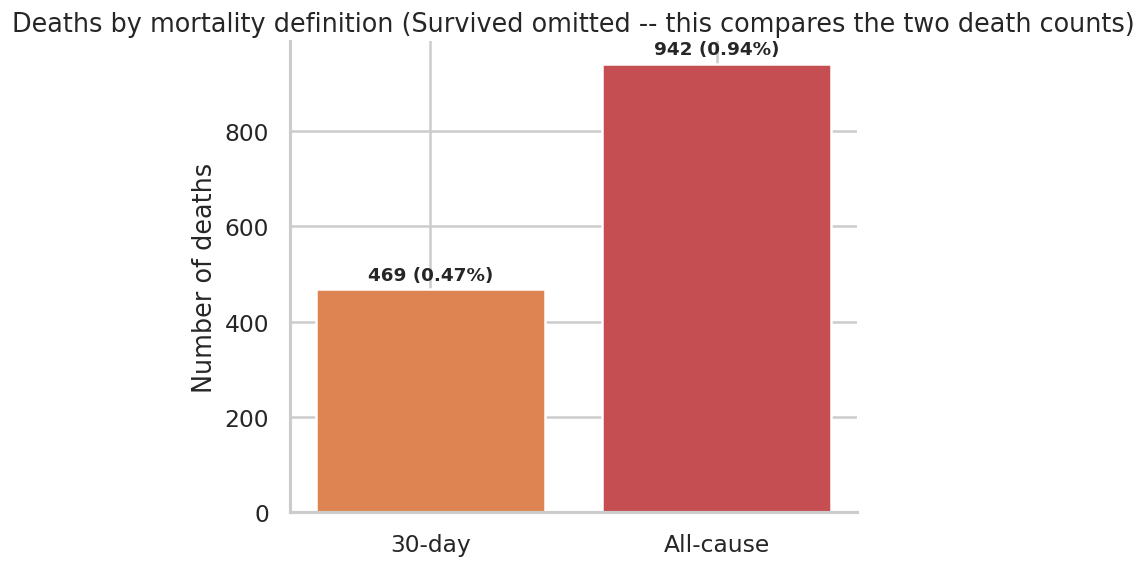

Currently using MORTALITY_DEFINITION = 'died_30day' for all mortality-rate
sections below (department, ICD-10, HFRS, multi-operation). Flip it in Cell 7 and
re-run from there to see those sections under the other definition.


In [10]:
# Cell 8b — All-cause death vs. 30-day death, side by side
def _summary(flag_col, label):
    n_died = cohort[flag_col].sum()
    n_total = len(cohort)
    return {
        'definition': label,
        'n_died': n_died,
        'n_survived': n_total - n_died,
        'death_rate_pct': n_died / n_total * 100,
        'pos_weight': (n_total - n_died) / n_died if n_died else float('nan'),
    }

comparison = pd.DataFrame([
    _summary('died_30day', '30-day (notes.md §4 definition)'),
    _summary('died_ever', 'All-cause (the 942-death folder count)'),
])
display(comparison)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['30-day', 'All-cause'], comparison['n_died'], color=['#DD8452', '#C44E52'])
for bar, row in zip(bars, comparison.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(comparison['n_died'])*0.02,
            f"{int(row.n_died)} ({row.death_rate_pct:.2f}%)", ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of deaths')
ax.set_title('Deaths by mortality definition (Survived omitted -- this compares the two death counts)')
fig.tight_layout()
save(fig, '01b_mortality_definition_comparison.png')
plt.show()

print(f"Currently using MORTALITY_DEFINITION = {MORTALITY_DEFINITION!r} for all mortality-rate")
print("sections below (department, ICD-10, HFRS, multi-operation). Flip it in Cell 7 and")
print("re-run from there to see those sections under the other definition.")


## 2. Demographics by outcome

Age, sex, and ASA physical status class are the three baseline pre-operative risk
indicators every surgeon already uses informally — this checks whether the cohort
matches clinical expectation (older, higher ASA class → more deaths) before trusting
anything more complex.


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/02a_age_boxplot.png


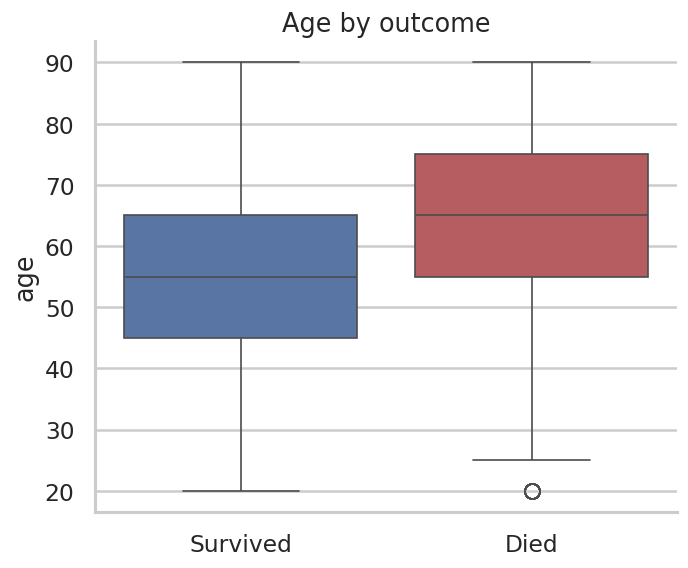

Saved: /content/inspire-analysis-thrisha/src/eda_outputs/02b_age_distribution_3way.png


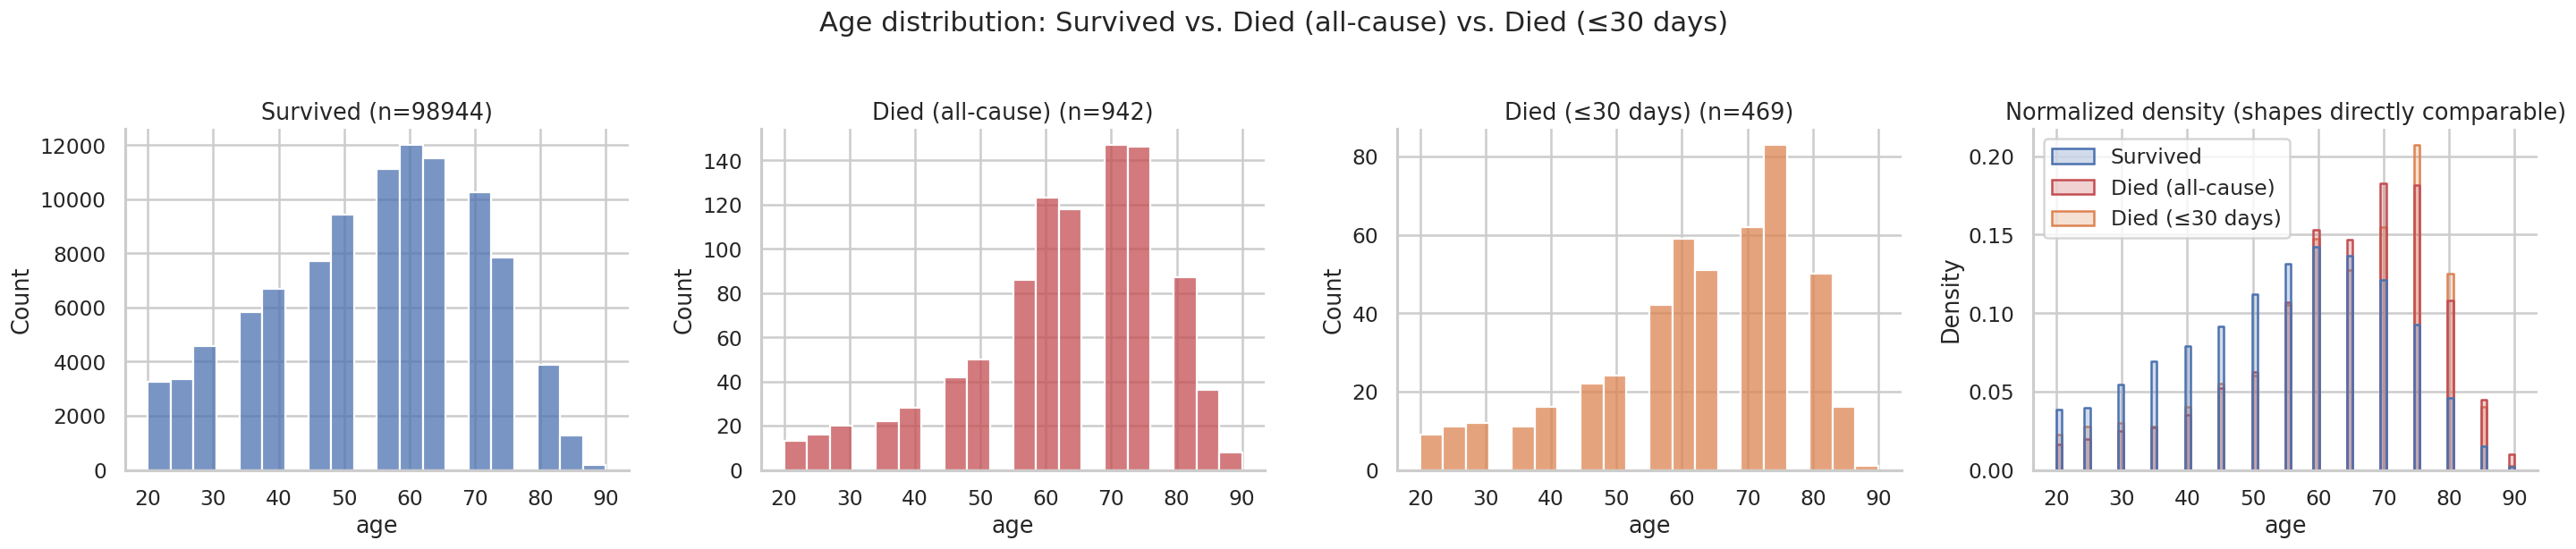

Median age — Survived: 55.0, Died (all-cause): 65.0, Died (≤30 days): 65.0


In [11]:
# Cell 9 — Age distribution by outcome
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=cohort, x='outcome', y='age', hue='outcome', palette=PALETTE,
            legend=False, ax=ax)
ax.set_title('Age by outcome')
ax.set_xlabel('')
fig.tight_layout()
save(fig, '02a_age_boxplot.png')
plt.show()

# A plain overlaid histogram would make Died invisible here -- at full scale it's
# 469 patients against 99,417 survived (~212x). Survived / Died (all-cause, 942) /
# Died (<=30 days, 469) each get their own panel -- note the two death groups overlap
# (every 30-day death is also counted in all-cause), this is a comparison, not a partition.
plot_three_groups(cohort, 'age', standard_three_groups(cohort),
                   'Age distribution: Survived vs. Died (all-cause) vs. Died (≤30 days)',
                   bins=20, filename='02b_age_distribution_3way.png')

median_age_survived = cohort.loc[~cohort['died_ever'], 'age'].median()
median_age_all = cohort.loc[cohort['died_ever'], 'age'].median()
median_age_30day = cohort.loc[cohort['died_30day'], 'age'].median()
print(f'Median age — Survived: {median_age_survived}, Died (all-cause): {median_age_all}, Died (≤30 days): {median_age_30day}')


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/03_asa_sex_by_outcome.png


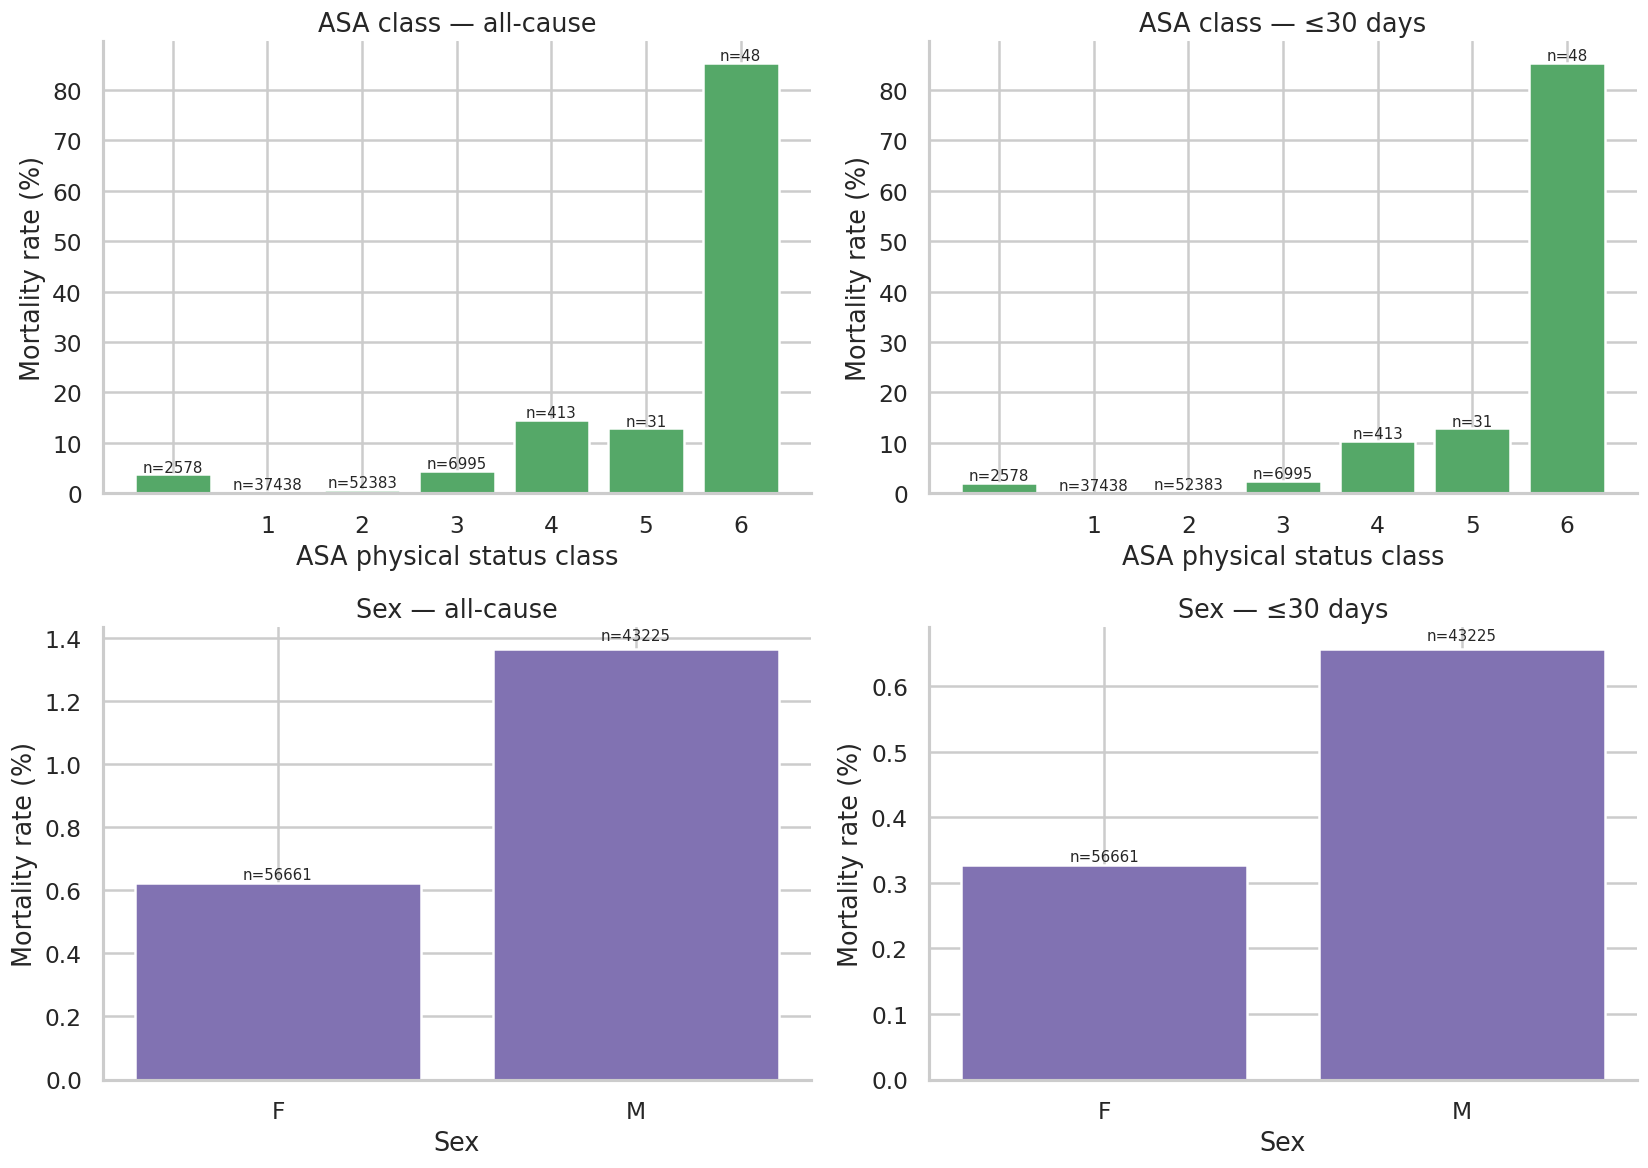

Interpretation: ASA class is a monotonic clinical severity scale (1=healthy, 5=moribund). If mortality % does not increase with ASA class here, that is worth investigating before trusting anything downstream — it would suggest a labelling or filtering problem. Comparing the all-cause and <=30-day panels also shows whether a variable's relationship with mortality holds under both definitions or is definition-dependent.


In [12]:
# Cell 10 — ASA class and sex vs. mortality rate, both definitions
# Previously this plotted stacked Survived%/Died% bars -- at the sex level the death
# rate is so small (~0.5%) that Died was visually zero against a 0-100 axis shared with
# Survived. Plotting mortality RATE directly (one bar per category, its own y-axis) is
# immune to that problem regardless of how imbalanced the classes are.

def _mortality_rate_table(group_col, death_col):
    t = cohort.groupby(group_col).agg(n_patients=('subject_id', 'count'), n_died=(death_col, 'sum'))
    t['mortality_rate'] = t['n_died'] / t['n_patients'] * 100
    return t

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, death_col, def_label in [(axes[0, 0], 'died_ever', 'all-cause'),
                                  (axes[0, 1], 'died_30day', '≤30 days')]:
    t = _mortality_rate_table('asa', death_col)
    bars = ax.bar(t.index.astype(str), t['mortality_rate'], color='#55A868')
    for bar, n in zip(bars, t['n_patients']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'n={n}', ha='center', fontsize=9)
    ax.set_ylabel('Mortality rate (%)')
    ax.set_xlabel('ASA physical status class')
    ax.set_title(f'ASA class — {def_label}')

for ax, death_col, def_label in [(axes[1, 0], 'died_ever', 'all-cause'),
                                  (axes[1, 1], 'died_30day', '≤30 days')]:
    t = _mortality_rate_table('sex', death_col)
    bars = ax.bar(t.index.astype(str), t['mortality_rate'], color='#8172B2')
    for bar, n in zip(bars, t['n_patients']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+bar.get_height()*0.02, f'n={n}', ha='center', fontsize=9)
    ax.set_ylabel('Mortality rate (%)')
    ax.set_xlabel('Sex')
    ax.set_title(f'Sex — {def_label}')

fig.tight_layout()
save(fig, '03_asa_sex_by_outcome.png')
plt.show()

print('Interpretation: ASA class is a monotonic clinical severity scale (1=healthy, 5=moribund). '
      'If mortality % does not increase with ASA class here, that is worth investigating before '
      'trusting anything downstream — it would suggest a labelling or filtering problem. Comparing '
      'the all-cause and <=30-day panels also shows whether a variable\'s relationship with mortality '
      'holds under both definitions or is definition-dependent.')


## 3. Department vs. mortality (15 departments)

Per `docs/notes.md` §15 item 3 — analysed on its own here, then re-checked jointly with
ICD-10 in Section 4, since department differences are partly just a proxy for which
diagnoses/operations that department handles.


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/04_department_mortality.png


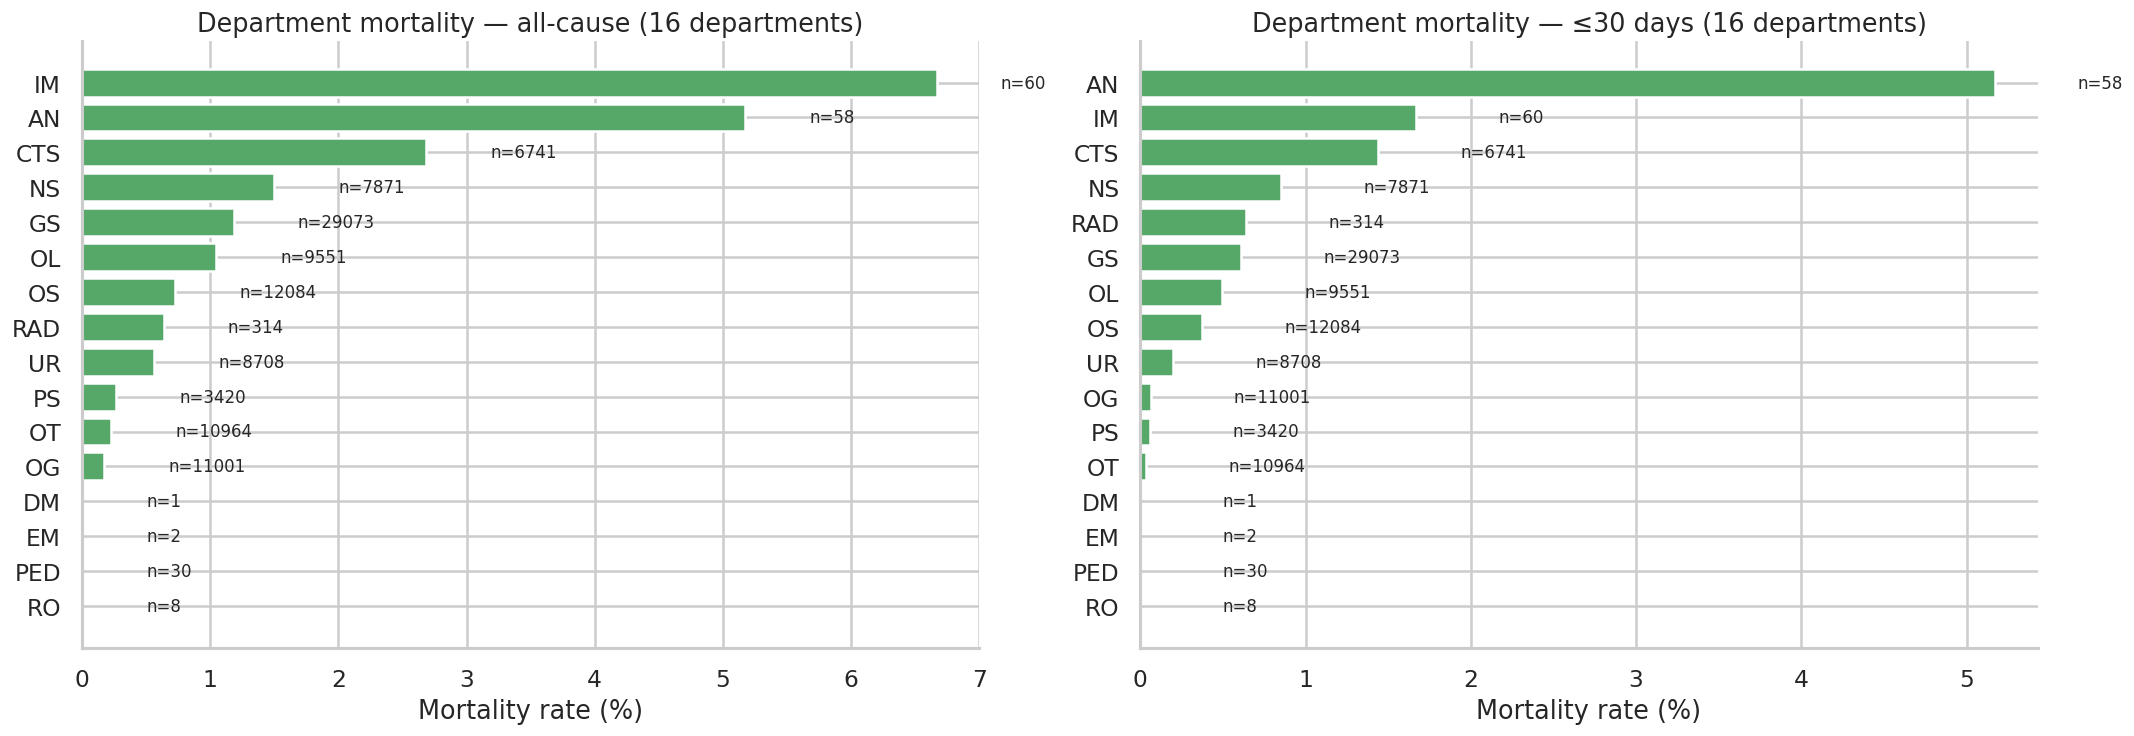

,department,n_patients,n_died,mortality_rate
5,IM,60,4,6.666667
0,AN,58,3,5.172414
1,CTS,6741,181,2.685062
6,NS,7871,118,1.499174
4,GS,29073,344,1.183228
8,OL,9551,100,1.047011
9,OS,12084,88,0.728236
13,RAD,314,2,0.636943
15,UR,8708,49,0.562701
12,PS,3420,9,0.263158


In [13]:
# Cell 11 — Mortality rate by department, both definitions side by side
def _dept_stats(death_col):
    t = cohort.groupby('department').agg(n_patients=('subject_id', 'count'), n_died=(death_col, 'sum')).reset_index()
    t['mortality_rate'] = t['n_died'] / t['n_patients'] * 100
    return t.sort_values('mortality_rate', ascending=False)

dept_all = _dept_stats('died_ever')
dept_30day = _dept_stats('died_30day')

fig, axes = plt.subplots(1, 2, figsize=(18, max(4, 0.4*len(dept_all))))
for ax, t, def_label in [(axes[0], dept_all, 'all-cause'), (axes[1], dept_30day, '≤30 days')]:
    bars = ax.barh(t['department'], t['mortality_rate'], color='#55A868')
    for bar, n in zip(bars, t['n_patients']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'n={n}', va='center', fontsize=10)
    ax.set_xlabel('Mortality rate (%)')
    ax.set_title(f'Department mortality — {def_label} ({len(t)} departments)')
    ax.invert_yaxis()
fig.tight_layout()
save(fig, '04_department_mortality.png')
plt.show()

display(dept_all)


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/05_department_mortality_by_emop.png


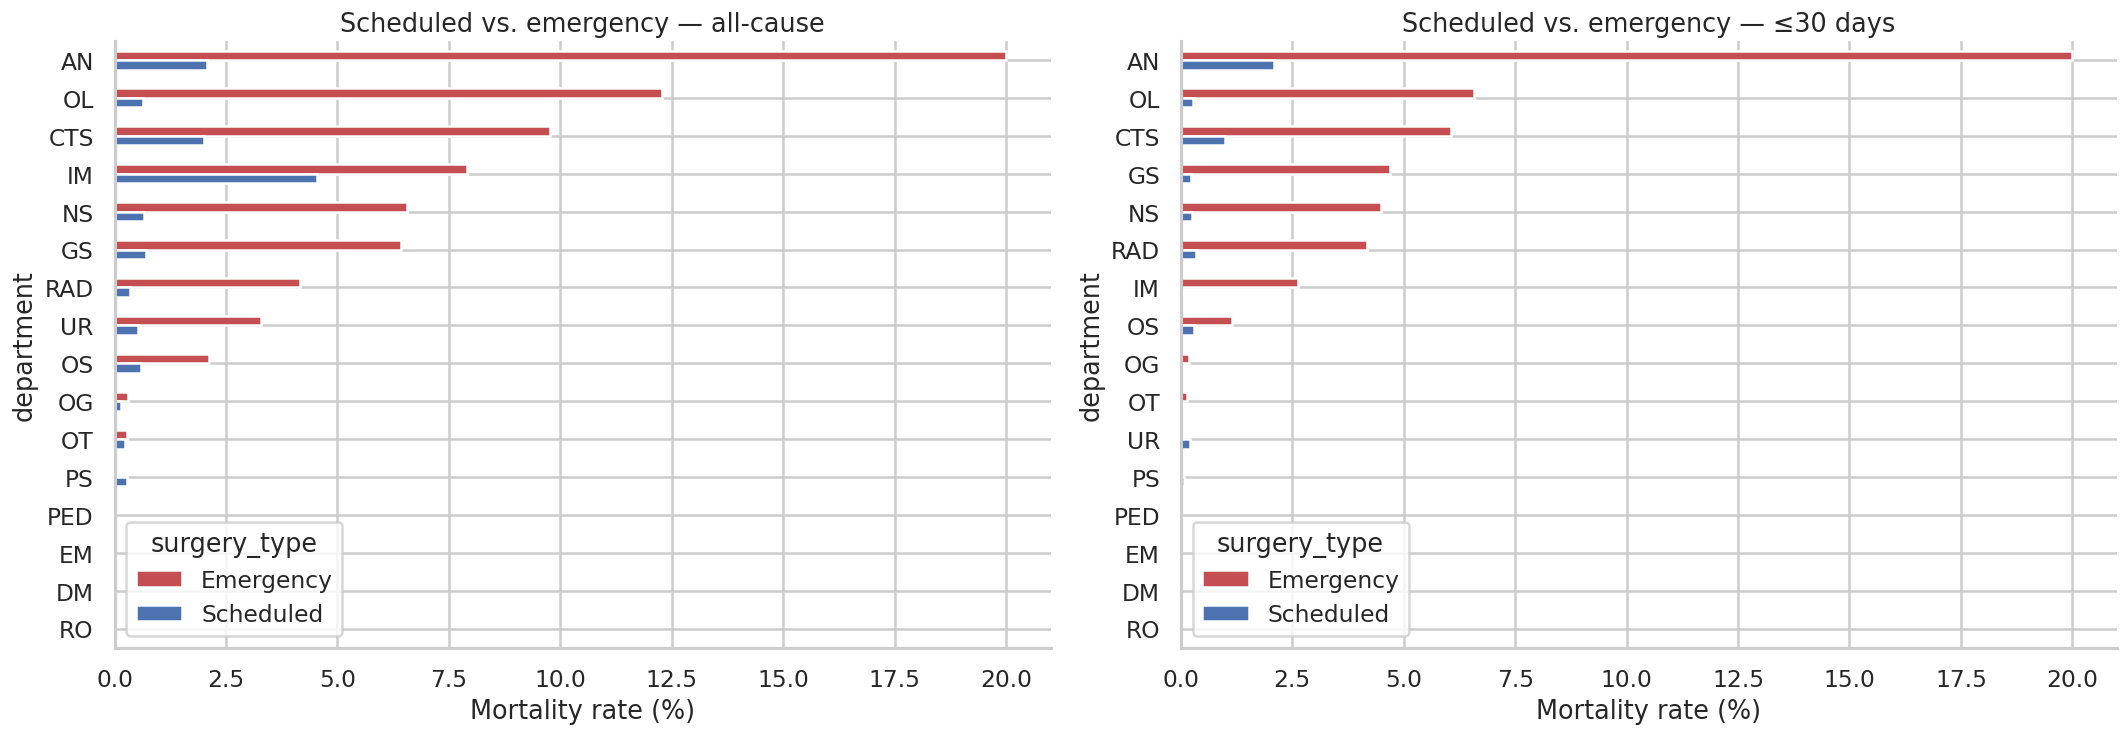

Interpretation: if emergency mortality is consistently higher than scheduled within the same department, that supports treating emop as a stratifying variable rather than just another feature — same logic as the frailty conditional-independence hypothesis in Section 11. Compare the two panels: a pattern that holds under both definitions is more trustworthy than one that only shows up under one.


In [14]:
# Cell 12 — Department mortality, stratified by scheduled vs. emergency, both definitions
def _dept_emop_pivot(death_col):
    t = cohort.groupby(['department', 'surgery_type']).agg(
        n_patients=('subject_id', 'count'), n_died=(death_col, 'sum')).reset_index()
    t['mortality_rate'] = t['n_died'] / t['n_patients'] * 100
    p = t.pivot(index='department', columns='surgery_type', values='mortality_rate')
    return p.sort_values(by=p.columns.tolist(), ascending=False, na_position='last')

pivot_all = _dept_emop_pivot('died_ever')
pivot_30day = _dept_emop_pivot('died_30day')

fig, axes = plt.subplots(1, 2, figsize=(18, max(4, 0.4*len(pivot_all))))
for ax, p, def_label in [(axes[0], pivot_all, 'all-cause'), (axes[1], pivot_30day, '≤30 days')]:
    p.plot(kind='barh', ax=ax, color=['#C44E52', '#4C72B0'])
    ax.set_xlabel('Mortality rate (%)')
    ax.set_title(f'Scheduled vs. emergency — {def_label}')
    ax.invert_yaxis()
fig.tight_layout()
save(fig, '05_department_mortality_by_emop.png')
plt.show()

print('Interpretation: if emergency mortality is consistently higher than scheduled within '
      'the same department, that supports treating emop as a stratifying variable rather '
      'than just another feature — same logic as the frailty conditional-independence '
      'hypothesis in Section 11. Compare the two panels: a pattern that holds under both '
      'definitions is more trustworthy than one that only shows up under one.')


## 4. ICD-10 diagnosis codes vs. mortality

Two things looked at separately, per `docs/notes.md` §15 item 2: which diagnosis codes
are most *common*, and which are most *associated with death* (not the same list — a rare
code with 100% mortality in 2 patients is noise, not signal, so a minimum-count filter is
applied).


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/06_top_icd10_diagnoses.png


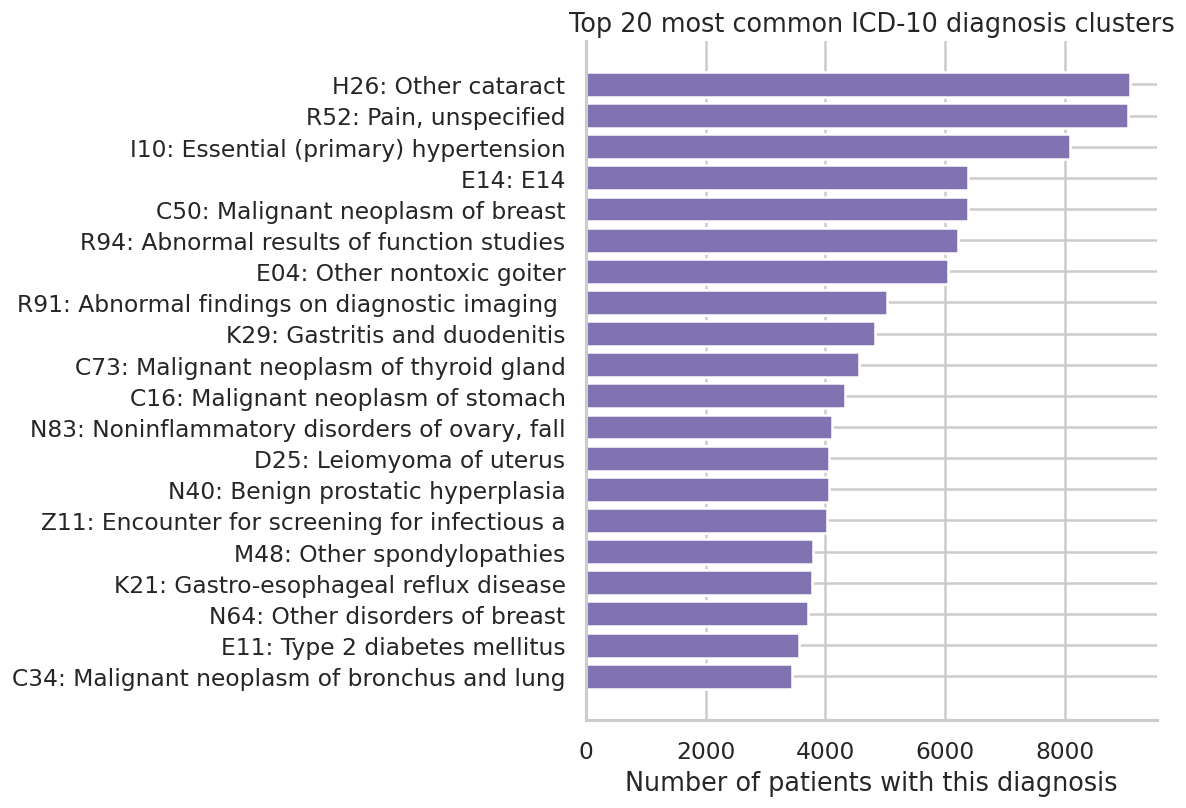

In [15]:
# Cell 13 — Most common ICD-10 diagnosis clusters, with descriptions
# all_clusters was already built during the Cell 7 streaming pass -- no need to
# re-walk the cohort here.
top_n = 20
top_clusters = pd.DataFrame(all_clusters.most_common(top_n), columns=['icd10_cluster', 'n_patients'])
top_clusters['description'] = top_clusters['icd10_cluster'].apply(icd10_description)
top_clusters['label'] = top_clusters['icd10_cluster'] + ': ' + top_clusters['description'].str.slice(0, 40)

fig, ax = plt.subplots(figsize=(10, max(4, 0.35*top_n)))
ax.barh(top_clusters['label'], top_clusters['n_patients'], color='#8172B2')
ax.set_xlabel('Number of patients with this diagnosis')
ax.set_title(f'Top {top_n} most common ICD-10 diagnosis clusters')
ax.invert_yaxis()
fig.tight_layout()
save(fig, '06_top_icd10_diagnoses.png')
plt.show()


MIN_PATIENTS threshold: 49 (cohort size 99886)
Saved: /content/inspire-analysis-thrisha/src/eda_outputs/07_icd10_diagnoses_mortality_risk.png


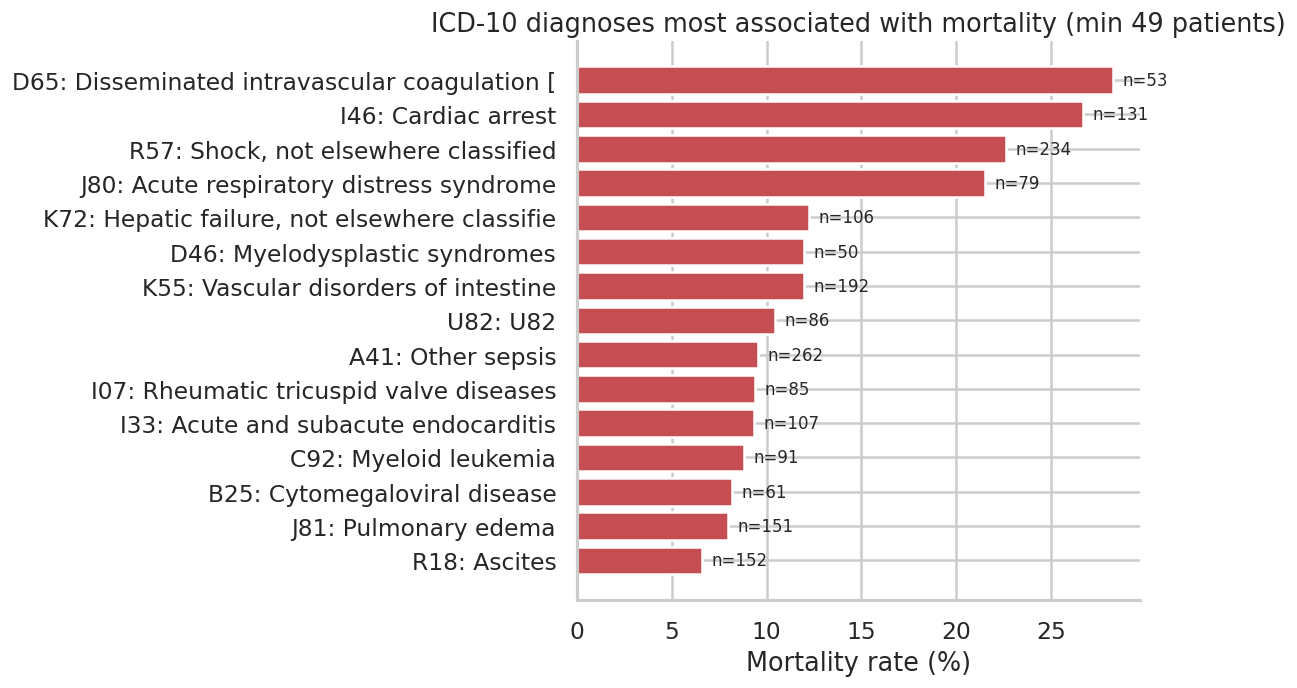

,icd10_cluster,description,n_patients,n_died,mortality_rate,label
382,D65,Disseminated intravascular coagulation [defibr...,53,15,28.301887,D65: Disseminated intravascular coagulation [
484,I46,Cardiac arrest,131,35,26.717557,I46: Cardiac arrest
142,R57,"Shock, not elsewhere classified",234,53,22.649573,"R57: Shock, not elsewhere classified"
434,J80,Acute respiratory distress syndrome,79,17,21.518987,J80: Acute respiratory distress syndrome
486,K72,"Hepatic failure, not elsewhere classified",106,13,12.264151,"K72: Hepatic failure, not elsewhere classifie"
510,D46,Myelodysplastic syndromes,50,6,12.000000,D46: Myelodysplastic syndromes
439,K55,Vascular disorders of intestine,192,23,11.979167,K55: Vascular disorders of intestine
361,U82,U82,86,9,10.465116,U82: U82
230,A41,Other sepsis,262,25,9.541985,A41: Other sepsis
520,I07,Rheumatic tricuspid valve diseases,85,8,9.411765,I07: Rheumatic tricuspid valve diseases


In [16]:
# Cell 14 — ICD-10 diagnosis clusters most associated with mortality (min-count filtered)
# Scale the threshold with cohort size: 5 patients is a reasonable floor at n=30, but at
# n=99,886 a code with only 5 patients is still noise -- 0.05% of the cohort minimum,
# floored at 5 so this still works on small subsets too.
MIN_PATIENTS = max(5, int(len(cohort) * 0.0005))
print(f'MIN_PATIENTS threshold: {MIN_PATIENTS} (cohort size {len(cohort)})')

records = []
for cluster in all_clusters:
    has_code = cohort['icd10_clusters'].apply(lambda lst: cluster in lst)
    n_with = has_code.sum()
    if n_with < MIN_PATIENTS:
        continue
    n_died_with = cohort.loc[has_code, 'died_flag'].sum()
    records.append({
        'icd10_cluster': cluster,
        'description': icd10_description(cluster),
        'n_patients': n_with,
        'n_died': n_died_with,
        'mortality_rate': n_died_with / n_with * 100,
    })

mortality_by_code = pd.DataFrame(records).sort_values('mortality_rate', ascending=False)
mortality_by_code['label'] = mortality_by_code['icd10_cluster'] + ': ' + mortality_by_code['description'].str.slice(0, 40)

top_risky = mortality_by_code.head(15)
fig, ax = plt.subplots(figsize=(10, max(4, 0.4*len(top_risky))))
bars = ax.barh(top_risky['label'], top_risky['mortality_rate'], color='#C44E52')
for bar, n in zip(bars, top_risky['n_patients']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'n={n}', va='center', fontsize=10)
ax.set_xlabel('Mortality rate (%)')
ax.set_title(f'ICD-10 diagnoses most associated with mortality (min {MIN_PATIENTS} patients)')
ax.invert_yaxis()
fig.tight_layout()
save(fig, '07_icd10_diagnoses_mortality_risk.png')
plt.show()

mortality_by_code.head(15)


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/08_multi_diagnosis_distribution_3way.png


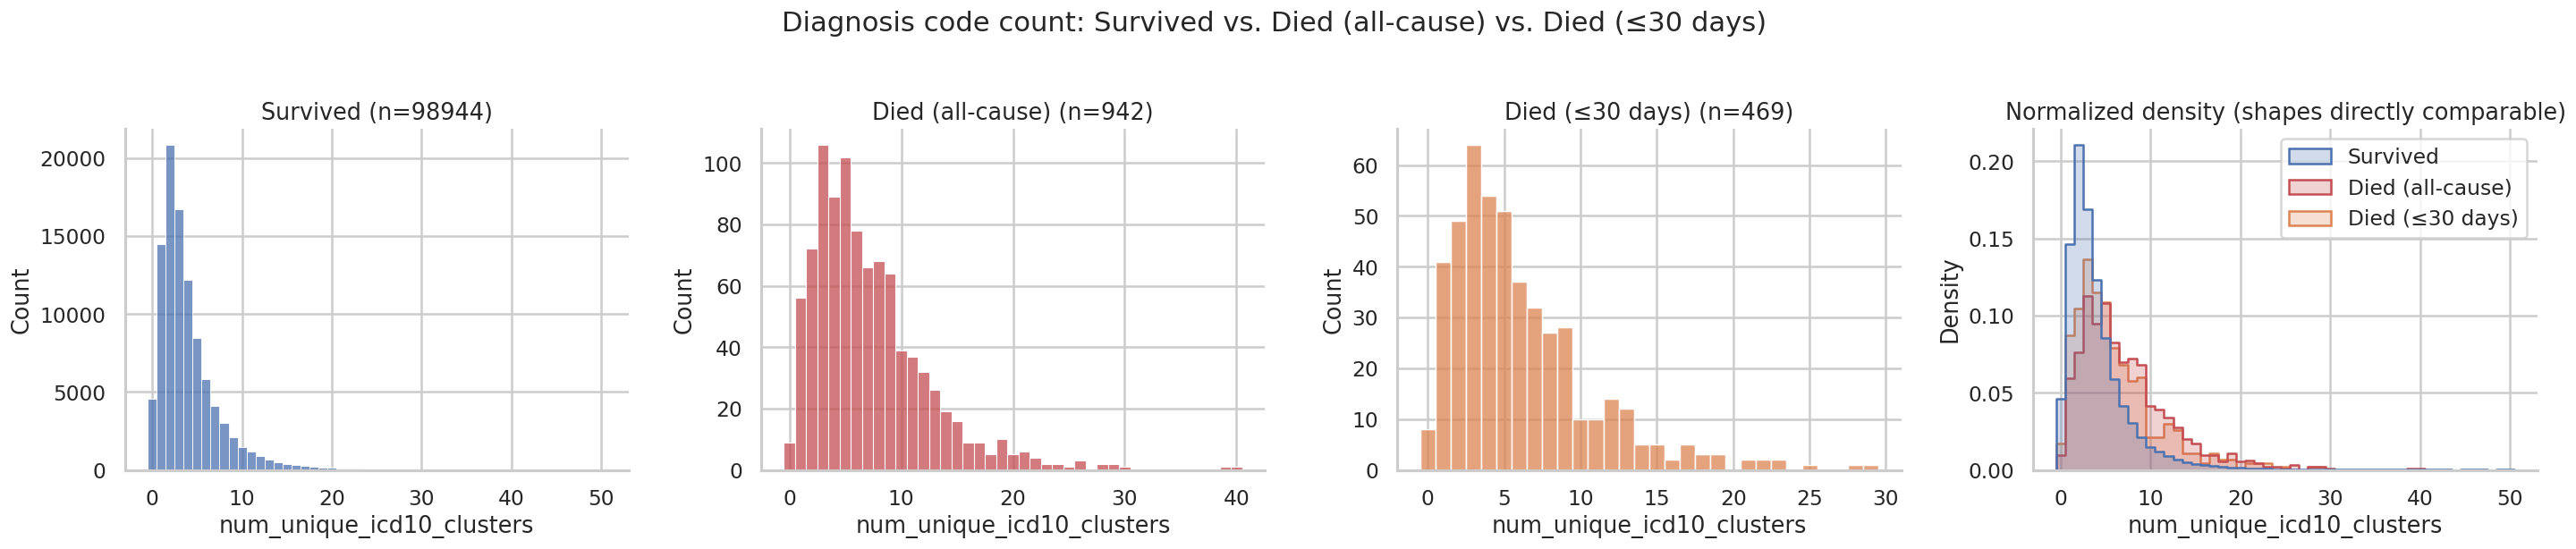

count    98944.000000
mean         4.010481
std          3.601559
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         50.000000
Name: Survived, dtype: float64

count    942.000000
mean       7.186837
std        5.231020
min        0.000000
25%        3.000000
50%        6.000000
75%        9.000000
max       40.000000
Name: Died (all-cause), dtype: float64

count    469.000000
mean       6.049041
std        4.672129
min        0.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       29.000000
Name: Died (≤30 days), dtype: float64

Interpretation: this motivates the item-2 decision in the roadmap — one-hot per code vs. code count vs. chapter grouping. If died patients systematically have more codes, a simple code-count feature may already carry signal before any weighting scheme.


In [17]:
# Cell 15 — Multi-diagnosis patients: how many distinct ICD-10 clusters does each patient have?
plot_three_groups(cohort, 'num_unique_icd10_clusters', standard_three_groups(cohort),
                   'Diagnosis code count: Survived vs. Died (all-cause) vs. Died (≤30 days)',
                   bins=20, discrete=True, filename='08_multi_diagnosis_distribution_3way.png')

print(cohort.loc[~cohort['died_ever'], 'num_unique_icd10_clusters'].describe().rename('Survived'))
print()
print(cohort.loc[cohort['died_ever'], 'num_unique_icd10_clusters'].describe().rename('Died (all-cause)'))
print()
print(cohort.loc[cohort['died_30day'], 'num_unique_icd10_clusters'].describe().rename('Died (≤30 days)'))
print('\nInterpretation: this motivates the item-2 decision in the roadmap — one-hot per '
      'code vs. code count vs. chapter grouping. If died patients systematically have more '
      'codes, a simple code-count feature may already carry signal before any weighting scheme.')


## 5. ICD-10 procedure codes (operations) vs. mortality

`icd10_pcs` answers *what was done*, not *what was wrong* — analysed separately per
`docs/notes.md` §5, using the same 3-character clustering convention as diagnoses for
consistency (PCS codes are structured differently from CM codes, so cluster boundaries
here are a simplification worth revisiting once this needs to go in the paper).


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/09_icd10_procedures_mortality.png


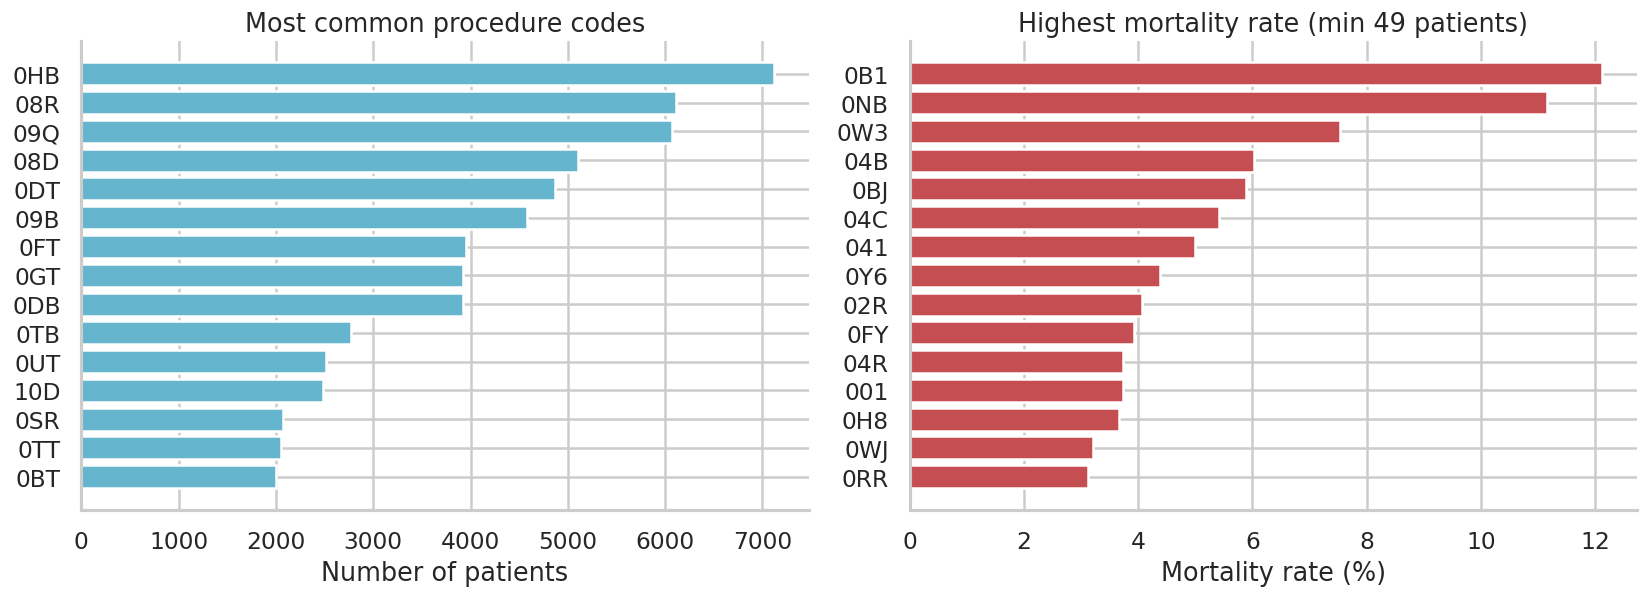

,icd10_pcs_cluster,n_patients,n_died,mortality_rate
28,0HB,7119,11,0.154516
9,08R,6113,4,0.065434
26,09Q,6066,19,0.313221
23,08D,5101,3,0.058812
3,0DT,4870,19,0.390144
2,09B,4581,8,0.174634
8,0FT,3957,23,0.581248
14,0GT,3926,1,0.025471
6,0DB,3920,12,0.306122
33,0TB,2768,17,0.614162


In [18]:
# Cell 16 — Most common procedure codes and their mortality rate
# all_pcs was already built during the Cell 7 streaming pass -- no need to re-walk here.
records = []
for pcs_cluster in all_pcs:
    has_code = cohort['icd10_pcs_codes'].apply(lambda lst: any(c.startswith(pcs_cluster) for c in lst))
    n_with = has_code.sum()
    n_died_with = cohort.loc[has_code, 'died_flag'].sum()
    records.append({
        'icd10_pcs_cluster': pcs_cluster,
        'n_patients': n_with,
        'n_died': n_died_with,
        'mortality_rate': n_died_with / n_with * 100 if n_with else 0,
    })

pcs_stats = pd.DataFrame(records).sort_values('n_patients', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.35*min(15, len(pcs_stats)))))

top_common = pcs_stats.head(15)
axes[0].barh(top_common['icd10_pcs_cluster'], top_common['n_patients'], color='#64B5CD')
axes[0].set_title('Most common procedure codes')
axes[0].set_xlabel('Number of patients')
axes[0].invert_yaxis()

filtered = pcs_stats[pcs_stats['n_patients'] >= MIN_PATIENTS].sort_values('mortality_rate', ascending=False).head(15)
axes[1].barh(filtered['icd10_pcs_cluster'], filtered['mortality_rate'], color='#C44E52')
axes[1].set_title(f'Highest mortality rate (min {MIN_PATIENTS} patients)')
axes[1].set_xlabel('Mortality rate (%)')
axes[1].invert_yaxis()

fig.tight_layout()
save(fig, '09_icd10_procedures_mortality.png')
plt.show()

pcs_stats.head(15)


## 6. Full 126-parameter feature coverage audit

Per `docs/notes.md` §15 item 5 — before deciding which of the 126 parameters to add,
check which ones actually have usable coverage in this cohort. Coverage = % of patients
with at least one measurement of that type.


In [19]:
# Cell 17 — Coverage audit across labs, ward_vitals, and vitals (intra-op)
# coverage_all was already built during the Cell 7 streaming pass -- this just summarises it.
n_labs_types = (coverage_all['table'] == 'labs').sum()
n_ward_types = (coverage_all['table'] == 'ward_vitals').sum()
n_vitals_types = (coverage_all['table'] == 'vitals').sum()
print(f'labs: {n_labs_types} distinct types found (schema has 38)')
print(f'ward_vitals: {n_ward_types} distinct types found (schema has 16)')
print(f'vitals (intra-op): {n_vitals_types} distinct types found (schema has 72)')
coverage_all.head(20)


labs: 38 distinct types found (schema has 38)
ward_vitals: 16 distinct types found (schema has 16)
vitals (intra-op): 74 distinct types found (schema has 72)


,table,feature,n_patients_with_measurement,coverage_pct,total_measurements,median_per_patient
0,labs,creatinine,99186,99.299201,1001373,10.095911
2,labs,hb,94521,94.628877,811208,8.582304
17,labs,hct,94419,94.526761,976162,10.338618
30,labs,wbc,94215,94.322528,755973,8.023913
21,labs,platelet,94154,94.261458,744486,7.907110
18,labs,calcium,93988,94.095269,672812,7.158488
22,labs,potassium,93955,94.062231,942971,10.036411
15,labs,sodium,93952,94.059228,939461,9.999372
7,labs,albumin,93786,93.893038,646157,6.889696
33,labs,phosphorus,93539,93.645756,665814,7.118036


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/10_feature_coverage_audit.png


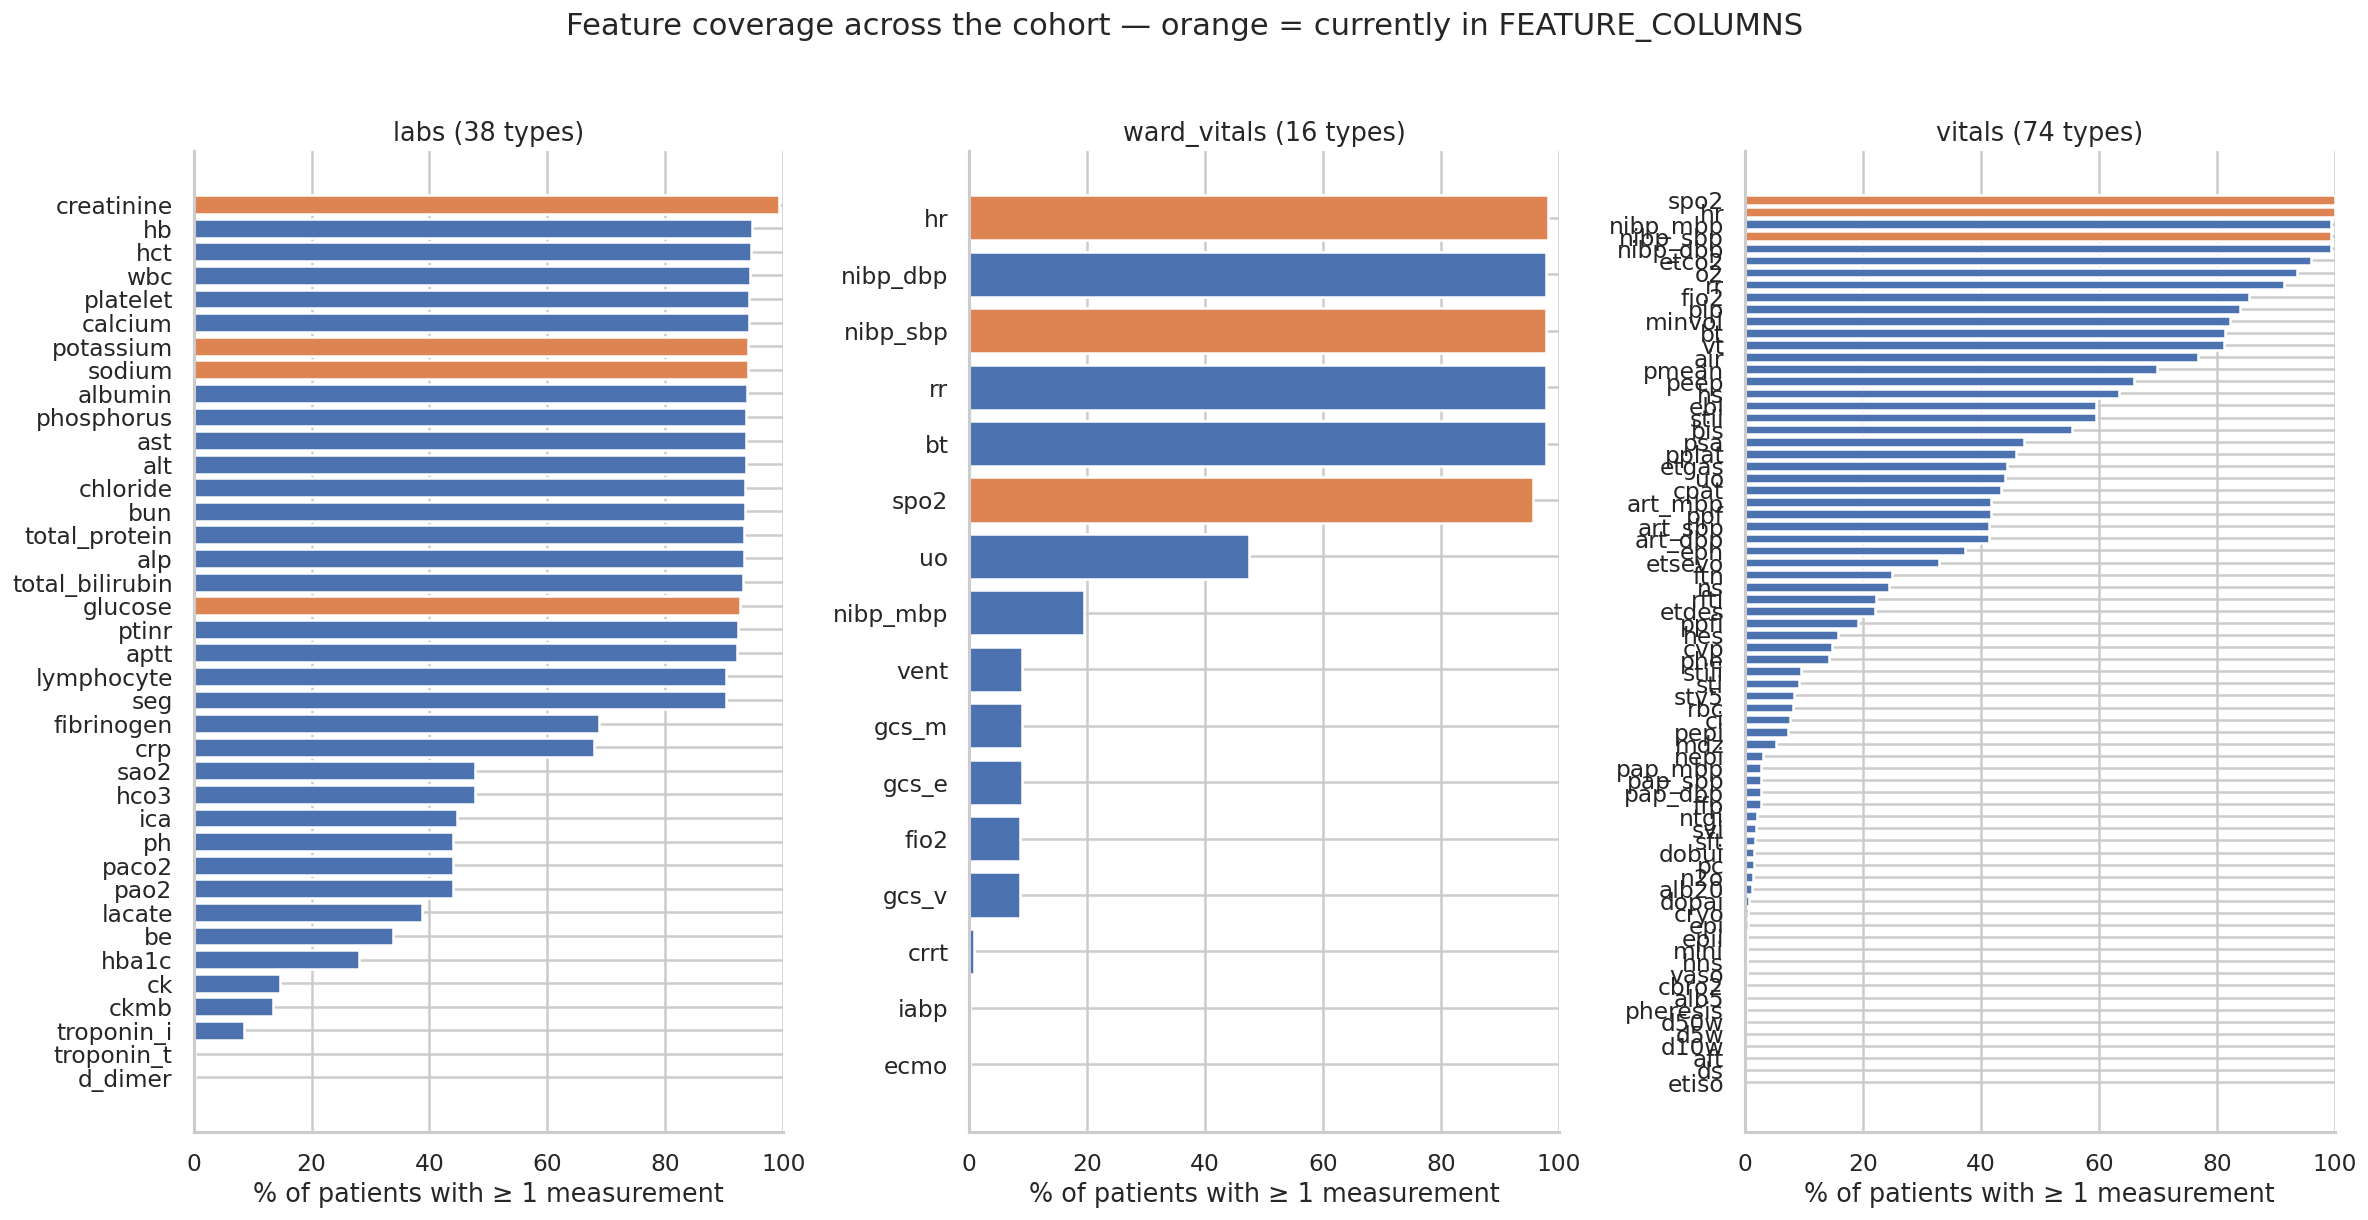

Interpretation: this is the first filter for expanding FEATURE_COLUMNS (notes.md §11 target list). A feature with <50% coverage on this small subset is a weak candidate regardless of clinical relevance — re-run this cell on the full 99,886-patient cohort before finalising, since coverage on 29 patients is not reliable at the tails.


In [20]:
# Cell 18 — Coverage plot per table, sorted, currently-used features highlighted
# CURRENT_FEATURES was already defined in Cell 7.

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for ax, table_name in zip(axes, ['labs', 'ward_vitals', 'vitals']):
    sub = coverage_all[coverage_all['table'] == table_name].sort_values('coverage_pct')
    colors = ['#DD8452' if f in CURRENT_FEATURES else '#4C72B0' for f in sub['feature']]
    ax.barh(sub['feature'], sub['coverage_pct'], color=colors)
    ax.set_title(f'{table_name} ({len(sub)} types)')
    ax.set_xlabel('% of patients with ≥ 1 measurement')
    ax.set_xlim(0, 100)

fig.suptitle('Feature coverage across the cohort — orange = currently in FEATURE_COLUMNS', y=1.02)
fig.tight_layout()
save(fig, '10_feature_coverage_audit.png')
plt.show()

print('Interpretation: this is the first filter for expanding FEATURE_COLUMNS (notes.md '
      '§11 target list). A feature with <50% coverage on this small subset is a weak '
      'candidate regardless of clinical relevance — re-run this cell on the full 99,886-patient '
      'cohort before finalising, since coverage on 29 patients is not reliable at the tails.')


## 7. Missingness pattern

Where the interpolation in the current pipeline (`align_time_series`, `docs/notes.md`
§8) is doing the most work — i.e. where gaps are largest.


Cohort has 99886 patients — sampling 300 (stratified by outcome) for the heatmap.
Saved: /content/inspire-analysis-thrisha/src/eda_outputs/11_missingness_heatmap.png


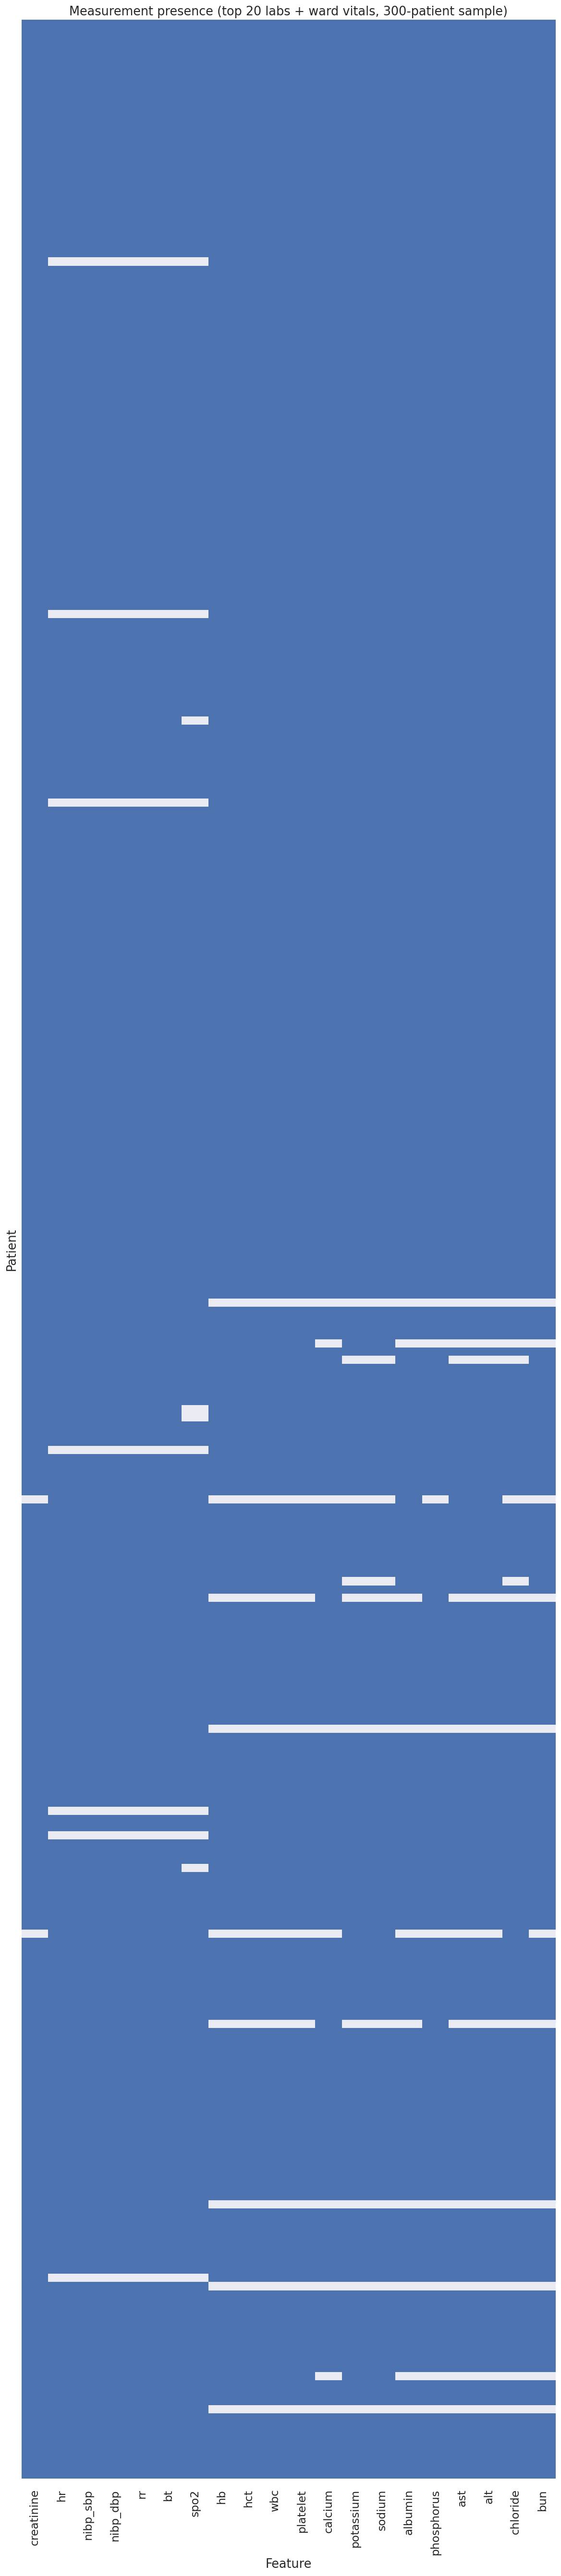

Interpretation: blue = at least one measurement exists; grey = fully missing for that patient. Vertical grey stripes flag a feature to reconsider; horizontal grey stripes flag a sparse patient (candidate for the min_observations filter in notes.md §13).


In [21]:
# Cell 19 — Missingness heatmap for the top labs + ward vitals by coverage
# Sampled to MAX_HEATMAP_PATIENTS: at full cohort scale (99,886 patients) a literal
# one-row-per-patient heatmap would be unreadable and slow to render. A random sample
# (stratified by outcome so both classes are visible) is representative for spotting
# feature-level and patient-level gaps without plotting all 99k rows.
TOP_K = 20
MAX_HEATMAP_PATIENTS = 300

top_features = coverage_all[coverage_all['table'].isin(['labs', 'ward_vitals'])] \
    .sort_values('coverage_pct', ascending=False).head(TOP_K)['feature'].tolist()

if len(cohort) > MAX_HEATMAP_PATIENTS:
    sample_ids = cohort.groupby('outcome', group_keys=False).apply(
        lambda g: g.sample(min(len(g), MAX_HEATMAP_PATIENTS // 2), random_state=42)
    )['subject_id'].tolist()
    print(f'Cohort has {len(cohort)} patients — sampling {len(sample_ids)} (stratified by outcome) for the heatmap.')
else:
    sample_ids = cohort['subject_id'].tolist()

presence_matrix = pd.DataFrame(index=sample_ids, columns=top_features, dtype=float)
for subject_id in sample_ids:
    # Re-open just this one file rather than needing a full in-memory subjects dict
    # (which Cell 7 deliberately avoids building at scale).
    subj = subject_module.Subject()
    subj.fromJSON(subject_path_lookup[subject_id])
    seen = set(r['item_name'] for r in subj.get_labs()) | set(r['item_name'] for r in subj.get_ward_vitals())
    for feat in top_features:
        presence_matrix.loc[subject_id, feat] = 1.0 if feat in seen else 0.0

fig, ax = plt.subplots(figsize=(10, max(6, 0.15*len(presence_matrix))))
sns.heatmap(presence_matrix.astype(float), cmap=['#EAEAF2', '#4C72B0'], cbar=False, ax=ax)
ax.set_xlabel('Feature')
ax.set_ylabel('Patient')
ax.set_yticks([])
ax.set_title(f'Measurement presence (top {TOP_K} labs + ward vitals, {len(presence_matrix)}-patient sample)')
fig.tight_layout()
save(fig, '11_missingness_heatmap.png')
plt.show()

print('Interpretation: blue = at least one measurement exists; grey = fully missing for that '
      'patient. Vertical grey stripes flag a feature to reconsider; horizontal grey stripes flag '
      'a sparse patient (candidate for the min_observations filter in notes.md §13).')


## 8. Currently-used feature distributions by outcome

The 7 features already in `FEATURE_COLUMNS` (`docs/notes.md` §9) — sanity-check that
each one separates survived vs. died in the expected clinical direction before trusting
the model's use of them.


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/12_current_features_by_outcome.png


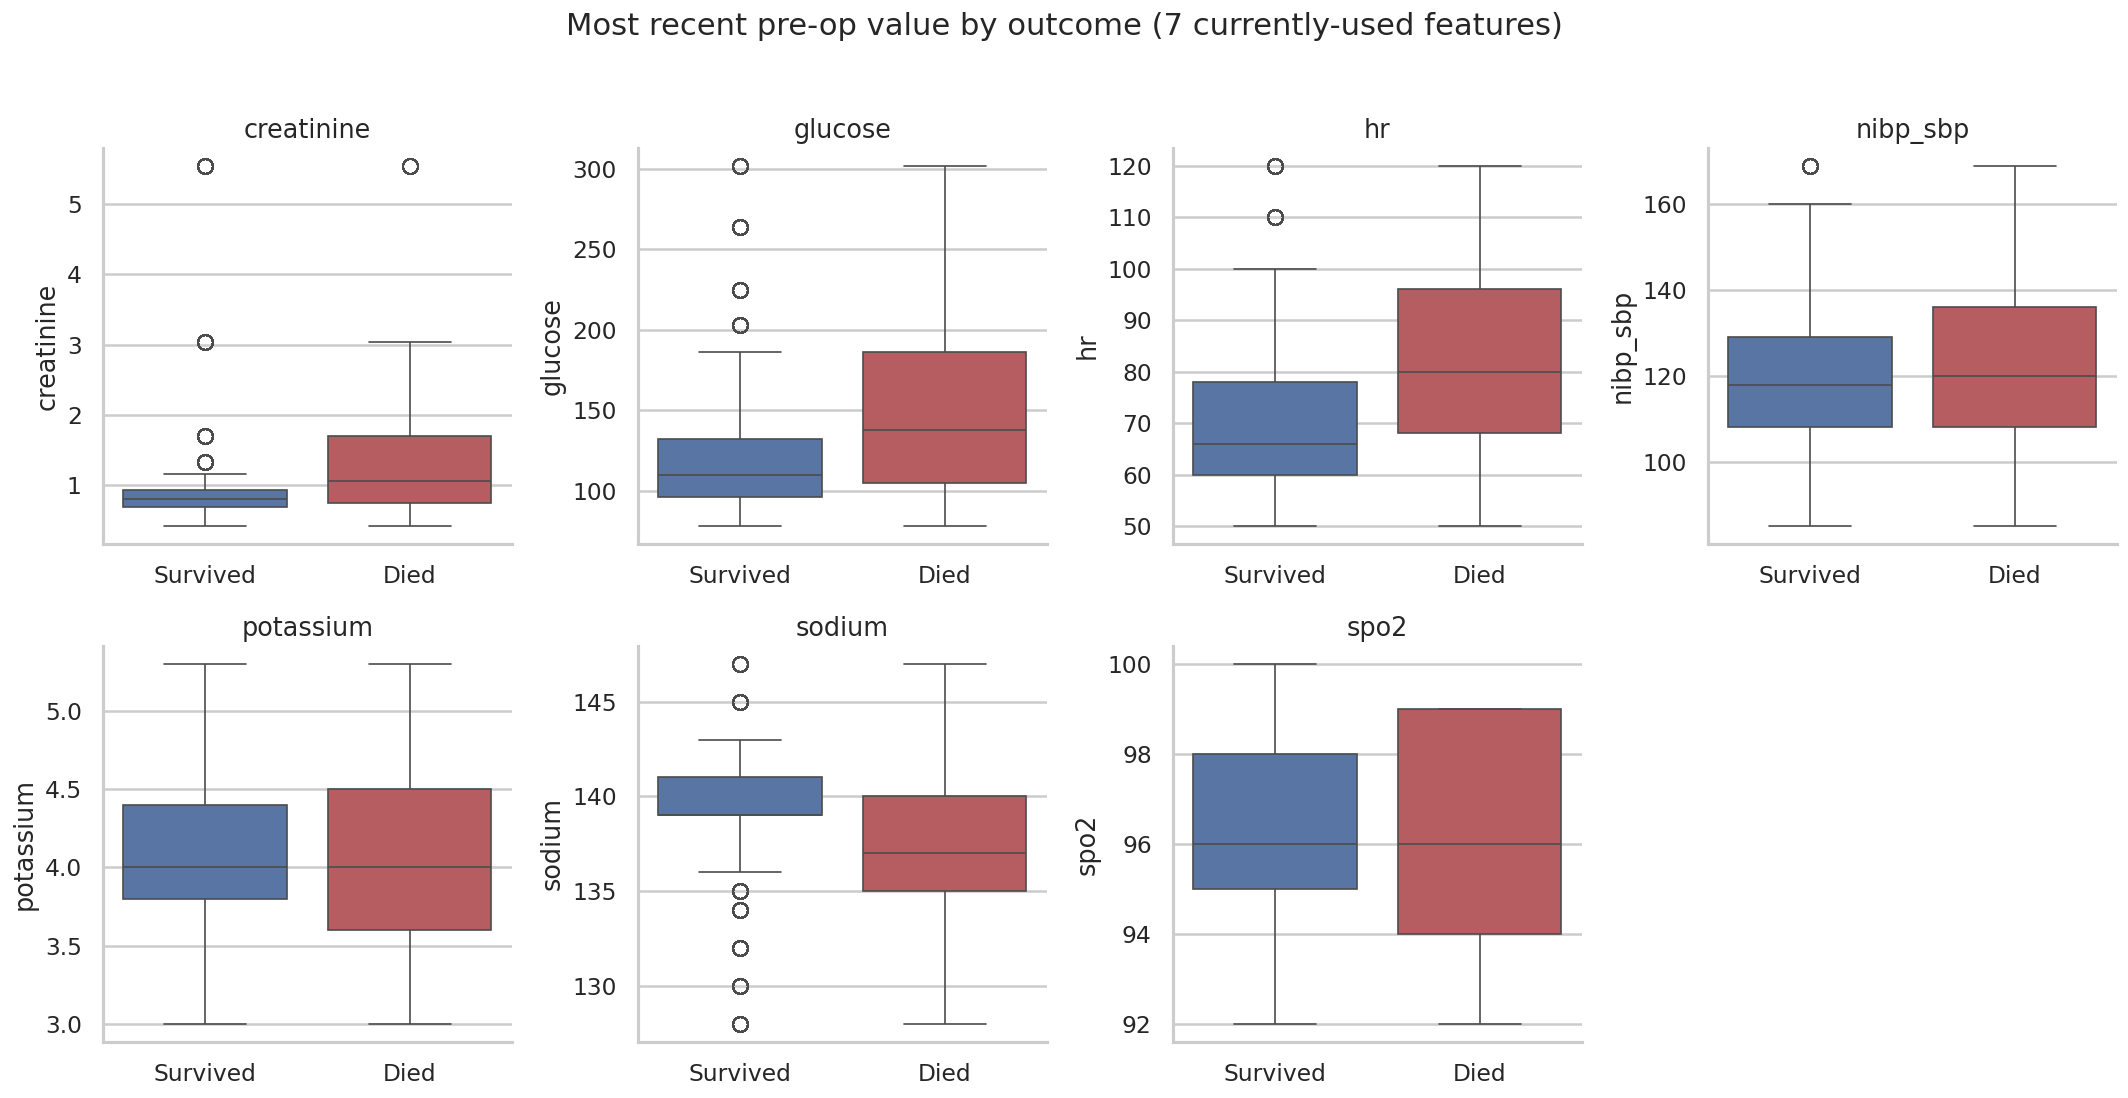

In [22]:
# Cell 20 — Distribution of the 7 currently-used features by outcome
# feature_df was already built during the Cell 7 streaming pass (searching both labs
# and ward_vitals per feature, since e.g. hr/spo2/nibp_sbp live in ward_vitals, not labs).
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
# Overlaying every individual point is only legible on small cohorts; at full scale
# (99,886 patients) it would be slow to draw and just render as a solid smear.
show_points = len(feature_df) <= 500
for ax, feat in zip(axes, sorted(CURRENT_FEATURES)):
    sns.boxplot(data=feature_df, x='outcome', y=feat, hue='outcome', palette=PALETTE,
                legend=False, showfliers=not show_points, ax=ax)
    if show_points:
        sns.stripplot(data=feature_df, x='outcome', y=feat, color='black', alpha=0.4, size=3, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
axes[-1].axis('off')
fig.suptitle('Most recent pre-op value by outcome (7 currently-used features)', y=1.02)
fig.tight_layout()
save(fig, '12_current_features_by_outcome.png')
plt.show()


## 9. Correlation structure (features + HFRS)

Extends the correlation work already noted in `docs/INSPIRE_Project_Notes.md` §11
(frailty–sodium −0.51, frailty–albumin −0.36) to the full set of currently-used
features plus the frailty score.


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/13_correlation_heatmap.png


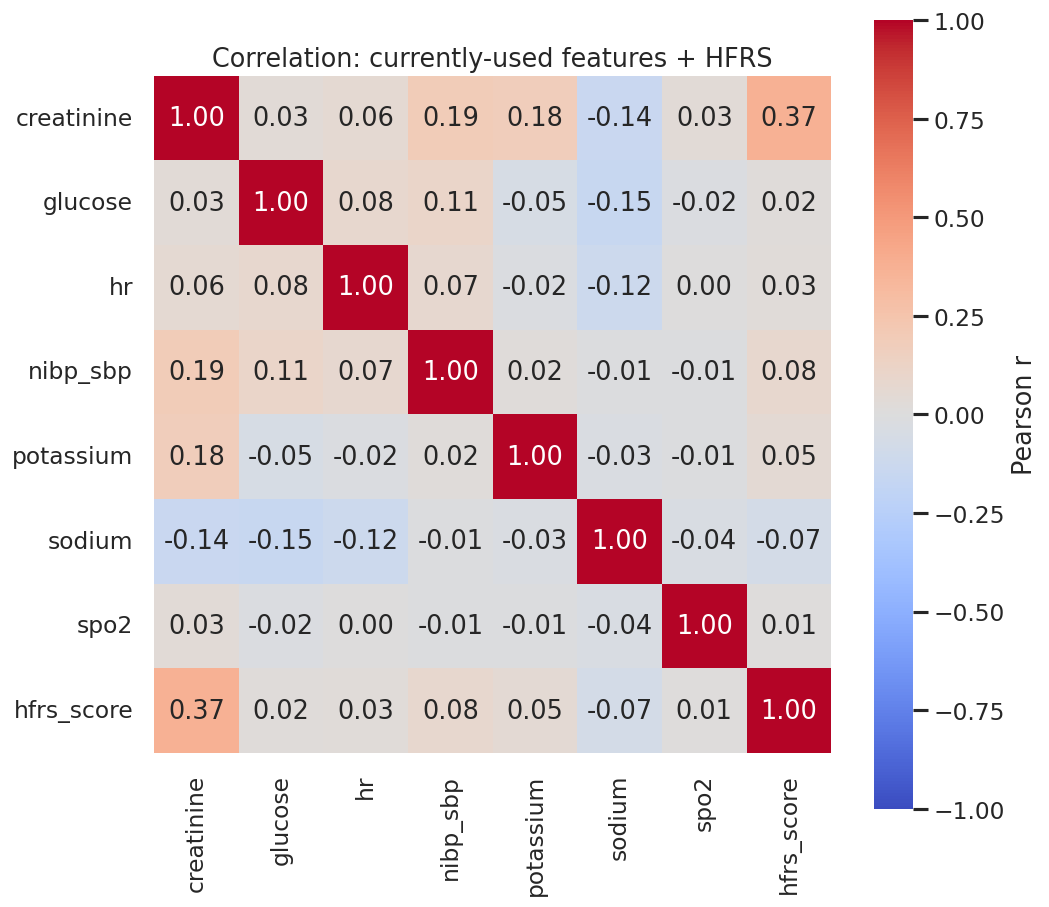

Interpretation: pairs with |r| > 0.7 among the 7 features are redundancy candidates (compare against the AST–ALT 0.90 finding already noted in INSPIRE_Project_Notes.md §11). HFRS row/column shows whether frailty tracks any single lab value closely enough to be redundant with it, or whether it is carrying independent signal.


In [23]:
# Cell 21 — Correlation heatmap
corr_df = feature_df[sorted(CURRENT_FEATURES)].copy()
corr_df['hfrs_score'] = cohort.set_index('subject_id').loc[feature_df['subject_id'], 'hfrs_score'].values

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation: currently-used features + HFRS')
fig.tight_layout()
save(fig, '13_correlation_heatmap.png')
plt.show()

print('Interpretation: pairs with |r| > 0.7 among the 7 features are redundancy candidates '
      '(compare against the AST–ALT 0.90 finding already noted in INSPIRE_Project_Notes.md §11). '
      'HFRS row/column shows whether frailty tracks any single lab value closely enough to be '
      'redundant with it, or whether it is carrying independent signal.')


## 10. HFRS frailty score and category vs. mortality

Uses the current `compute_hfrs()` as-is. Per `docs/notes.md` §15 item 9, this
implementation does **not** yet apply the 2-year time window from Gilbert et al. 2018 —
treat these numbers as a first pass, not final.


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/14a_hfrs_distribution_3way.png


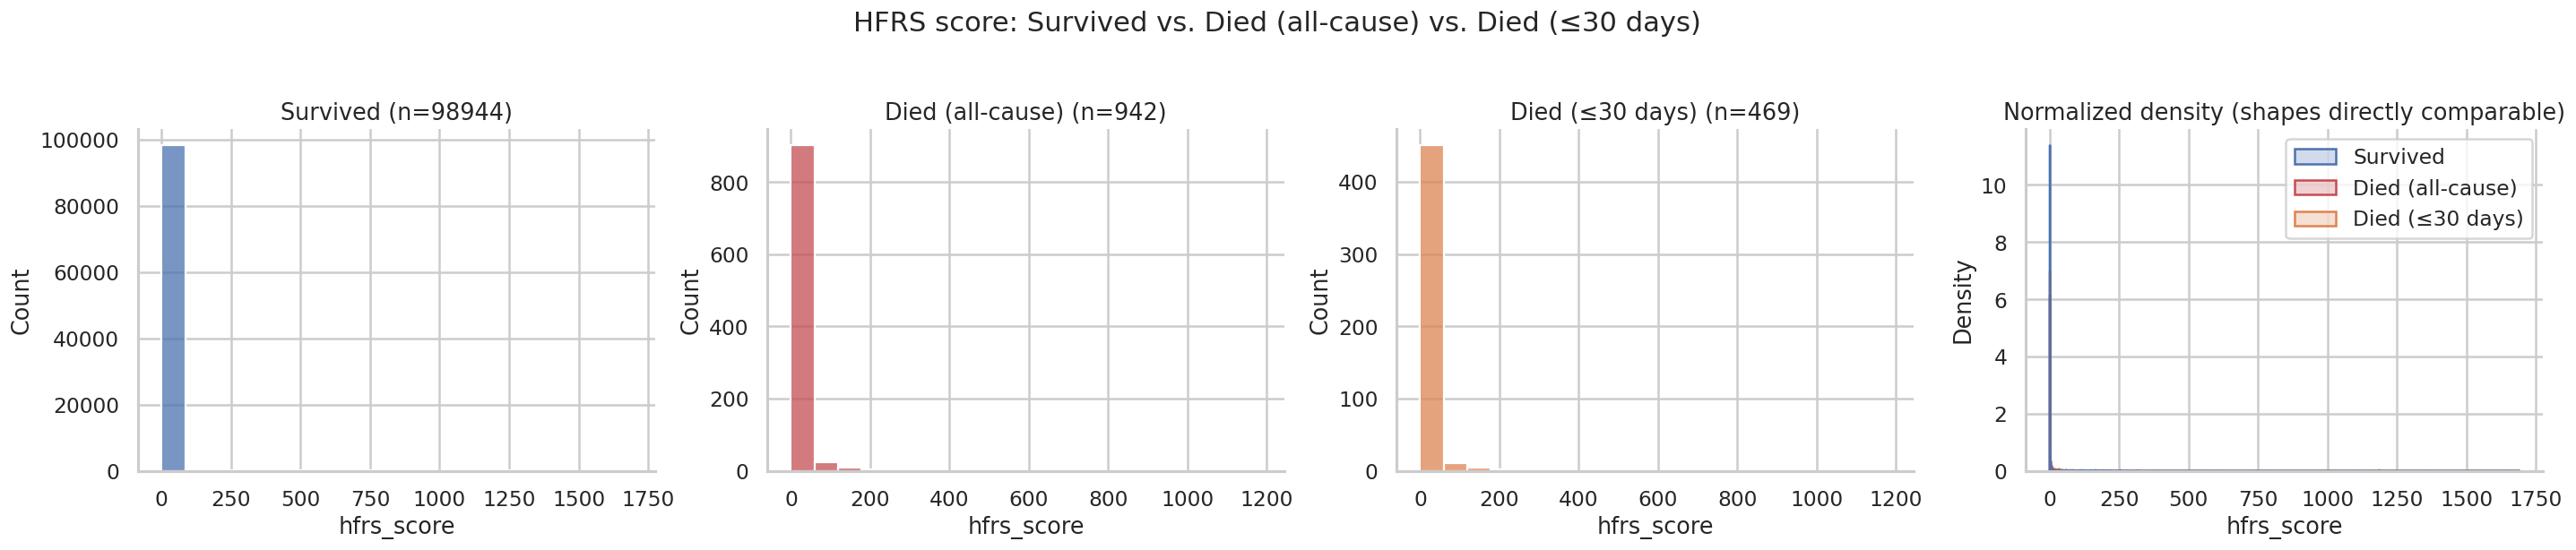

Saved: /content/inspire-analysis-thrisha/src/eda_outputs/14b_hfrs_vs_mortality.png


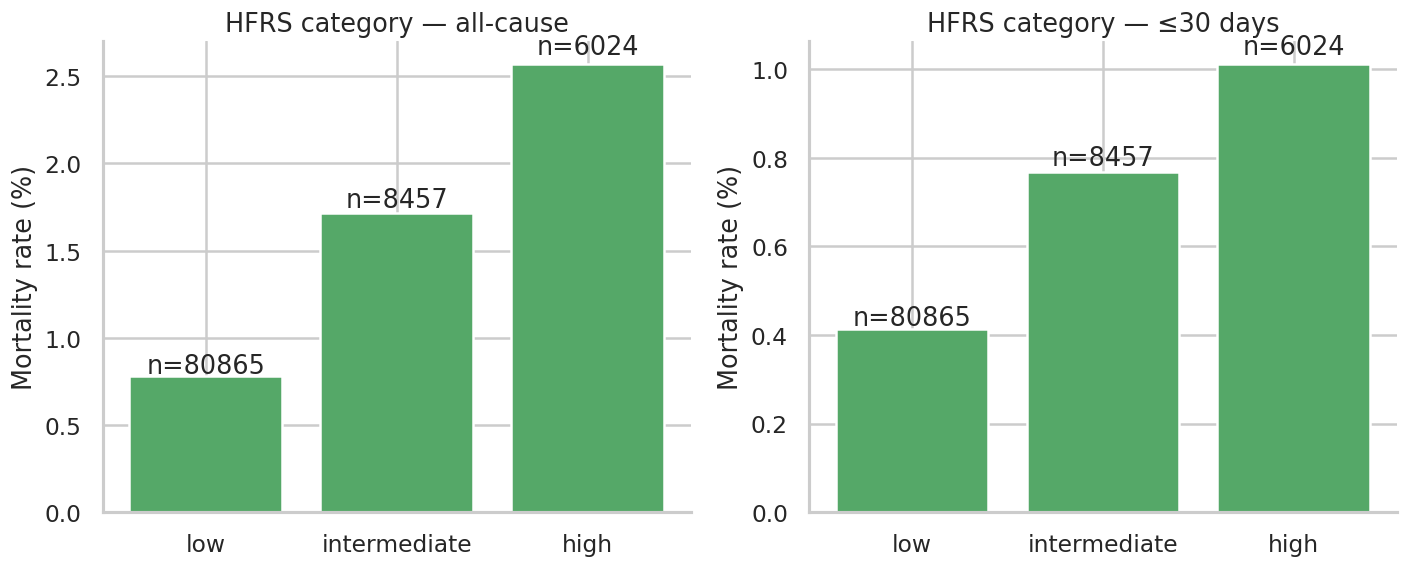

Sanity check against Gilbert et al. 2018: their highest-risk group had OR 1.71 for 30-day mortality vs. the lowest-risk group. Compare that ratio to the mortality-rate ratio between the high and low bars above — a wildly different ratio here (small n aside) is a flag to prioritise the 2-year time-window fix before trusting this further.


In [24]:
# Cell 22 — HFRS distribution and mortality by category, both definitions
plot_three_groups(cohort, 'hfrs_score', standard_three_groups(cohort),
                   'HFRS score: Survived vs. Died (all-cause) vs. Died (≤30 days)',
                   bins=20, filename='14a_hfrs_distribution_3way.png')

def _hfrs_mortality(death_col):
    t = cohort.groupby('hfrs_category').agg(
        n_patients=('subject_id', 'count'), n_died=(death_col, 'sum')
    ).reindex(['low', 'intermediate', 'high']).reset_index()
    t['mortality_rate'] = t['n_died'] / t['n_patients'] * 100
    return t

hfrs_all = _hfrs_mortality('died_ever')
hfrs_30day = _hfrs_mortality('died_30day')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, t, def_label in [(axes[0], hfrs_all, 'all-cause'), (axes[1], hfrs_30day, '≤30 days')]:
    bars = ax.bar(t['hfrs_category'], t['mortality_rate'], color='#55A868')
    for bar, n in zip(bars, t['n_patients']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+bar.get_height()*0.02, f'n={n}', ha='center')
    ax.set_ylabel('Mortality rate (%)')
    ax.set_title(f'HFRS category — {def_label}')
fig.tight_layout()
save(fig, '14b_hfrs_vs_mortality.png')
plt.show()

print('Sanity check against Gilbert et al. 2018: their highest-risk group had OR 1.71 for '
      '30-day mortality vs. the lowest-risk group. Compare that ratio to the mortality-rate '
      'ratio between the high and low bars above — a wildly different ratio here (small n aside) '
      'is a flag to prioritise the 2-year time-window fix before trusting this further.')


## 11. Conditional dependency preview: frailty × scheduled/emergency

Preview of the hypothesis in `docs/notes.md` §15 item 10 — frailty should matter more
for emergency surgery than scheduled surgery, because scheduled surgery already
pre-selects for fitness.


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/15_frailty_x_surgery_type.png


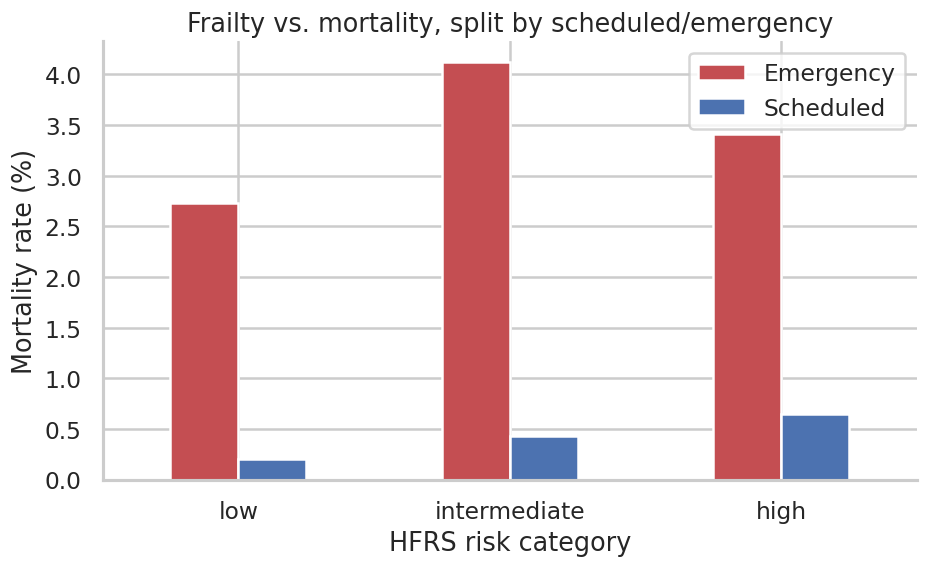

Interpretation: the hypothesis predicts a steep frailty-category slope for Emergency and a much flatter slope for Scheduled. On a small subset this will be noisy — treat as a shape check, not a conclusion; re-run at full scale before citing in the paper.


In [25]:
# Cell 23 — Mortality rate by HFRS category, split by surgery type
cross = cohort.groupby(['surgery_type', 'hfrs_category']).agg(
    n_patients=('subject_id', 'count'), n_died=('died_flag', 'sum')
).reset_index()
cross['mortality_rate'] = cross['n_died'] / cross['n_patients'] * 100

pivot = cross.pivot(index='hfrs_category', columns='surgery_type', values='mortality_rate') \
    .reindex(['low', 'intermediate', 'high'])

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind='bar', ax=ax, color=['#C44E52', '#4C72B0'])
ax.set_ylabel('Mortality rate (%)')
ax.set_xlabel('HFRS risk category')
ax.set_title('Frailty vs. mortality, split by scheduled/emergency')
ax.legend(title='')
plt.xticks(rotation=0)
fig.tight_layout()
save(fig, '15_frailty_x_surgery_type.png')
plt.show()

print('Interpretation: the hypothesis predicts a steep frailty-category slope for Emergency '
      'and a much flatter slope for Scheduled. On a small subset this will be noisy — treat '
      'as a shape check, not a conclusion; re-run at full scale before citing in the paper.')


## 12. Multi-operation patients vs. mortality

Per `docs/notes.md` §15 item 11 — a patient-level question, distinct from the
per-operation prediction the pipeline currently makes.


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/16_multi_operation_mortality.png


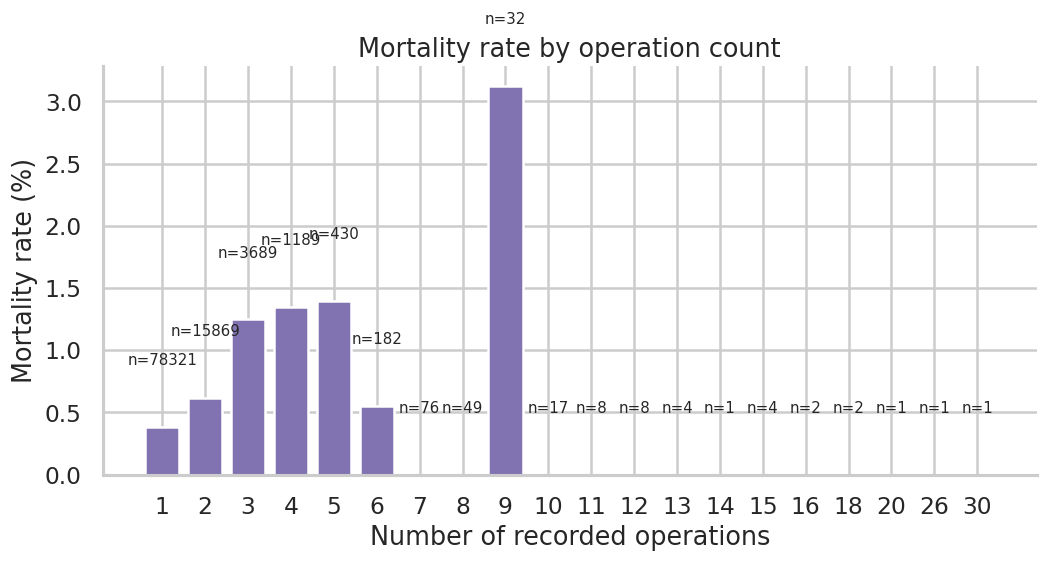

Interpretation: watch for a monotonic increase (more operations -> sicker patient, higher risk) vs. a flat/noisy pattern (operation count is not itself informative once other features are known). Small-n categories (single patients) will be unreliable.


In [26]:
# Cell 24 — Mortality rate by number of operations
op_stats = cohort.groupby('num_operations').agg(
    n_patients=('subject_id', 'count'), n_died=('died_flag', 'sum')
).reset_index()
op_stats['mortality_rate'] = op_stats['n_died'] / op_stats['n_patients'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(op_stats['num_operations'].astype(str), op_stats['mortality_rate'], color='#8172B2')
for bar, n in zip(bars, op_stats['n_patients']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'n={n}', ha='center', fontsize=9)
ax.set_xlabel('Number of recorded operations')
ax.set_ylabel('Mortality rate (%)')
ax.set_title('Mortality rate by operation count')
fig.tight_layout()
save(fig, '16_multi_operation_mortality.png')
plt.show()

print('Interpretation: watch for a monotonic increase (more operations -> sicker patient, '
      'higher risk) vs. a flat/noisy pattern (operation count is not itself informative once '
      'other features are known). Small-n categories (single patients) will be unreliable.')


## 13. Time-series measurement density (worked patient example)

Same style as the worked example in `docs/notes.md` §6 (subject 100033460) — shows
*when*, not just *what*, was measured, which is what the interpolation/masking scheme in
the pipeline (§8) has to fill in.


Saved: /content/inspire-analysis-thrisha/src/eda_outputs/17_measurement_density_example.png


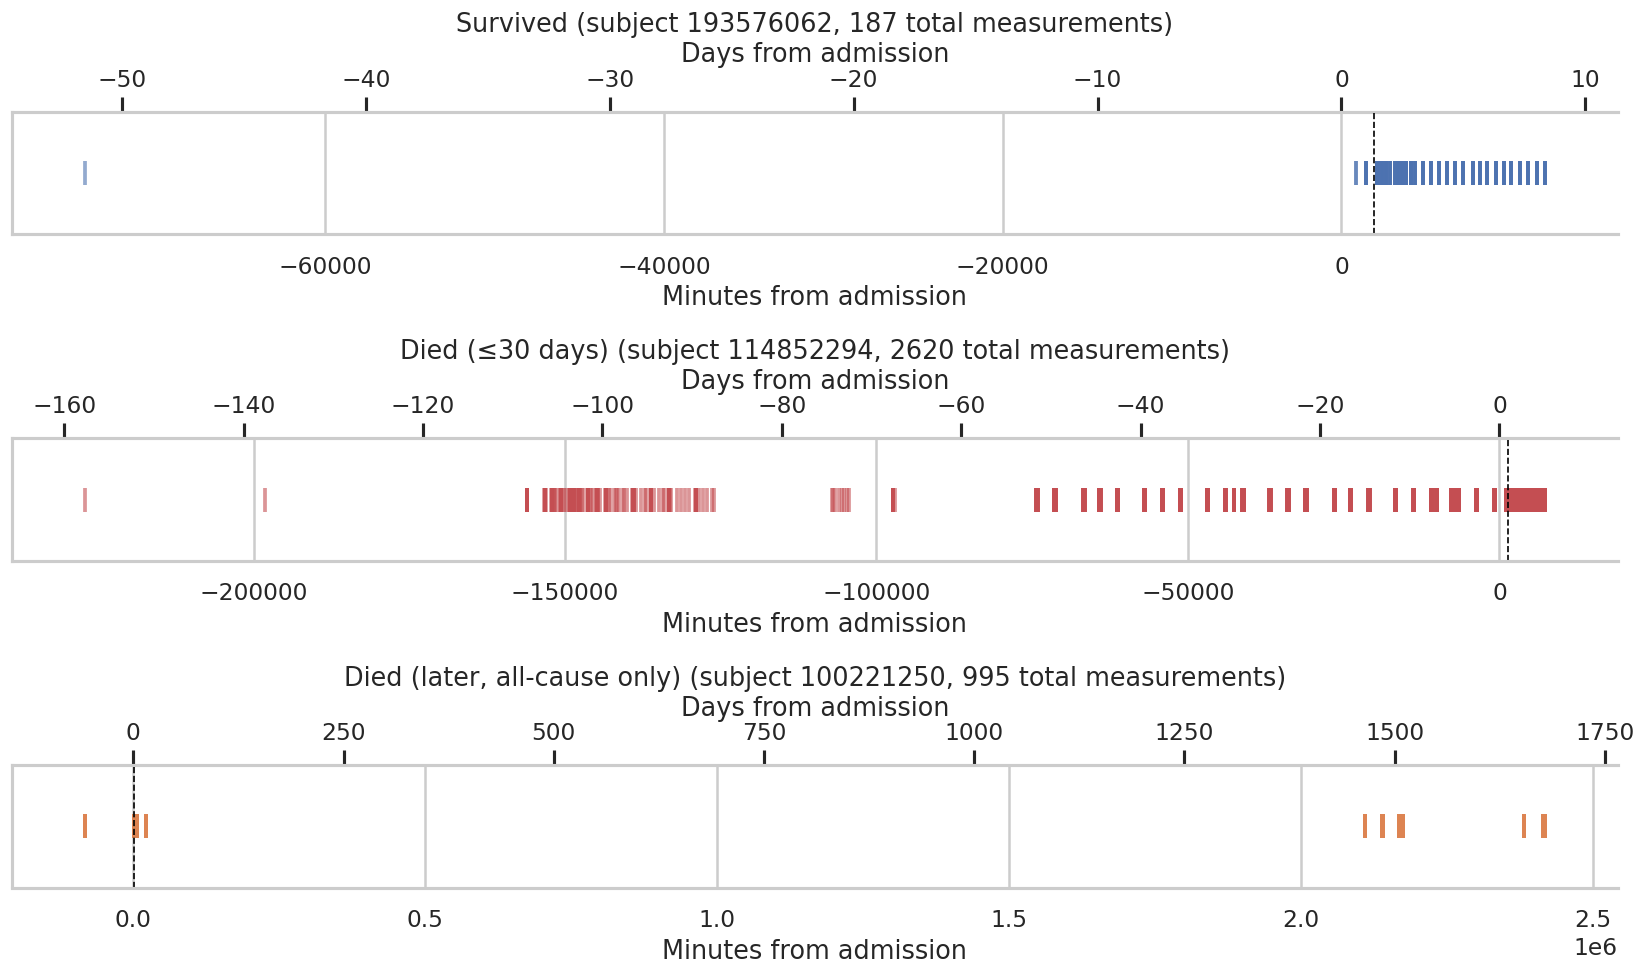

Interpretation: gaps in the tick marks are exactly what align_time_series() (notes.md §8) has to bridge with linear interpolation — large gaps right before surgery are the highest-risk spots for the model to be reasoning from stale/interpolated data.


In [27]:
# Cell 25 — Measurement density over time: Survived / Died (<=30 days) / Died (later, all-cause only)
survived_ids = cohort.loc[~cohort['died_ever'], 'subject_id']
died_30day_ids = cohort.loc[cohort['died_30day'], 'subject_id']
died_later_ids = cohort.loc[cohort['died_ever'] & ~cohort['died_30day'], 'subject_id']

example_survived = survived_ids.iloc[0] if len(survived_ids) else None
example_died_30day = died_30day_ids.iloc[0] if len(died_30day_ids) else None
example_died_later = died_later_ids.iloc[0] if len(died_later_ids) else None

def plot_measurement_density(ax, subject_id, label, color):
    # Re-open just this one file rather than needing a full in-memory subjects dict.
    subj = subject_module.Subject()
    subj.fromJSON(subject_path_lookup[subject_id])
    times = [int(r['chart_time']) for r in subj.get_labs()] + \
            [int(r['chart_time']) for r in subj.get_ward_vitals()]
    ax.scatter(times, [1]*len(times), marker='|', s=200, color=color, alpha=0.6)
    first_op = subj.get_first_operation()
    orin_time = int(first_op['orin_time'])
    ax.axvline(orin_time, color='black', linestyle='--', linewidth=1, label='Surgery start')
    ax.set_yticks([])
    ax.set_title(f'{label} (subject {subject_id}, {len(times)} total measurements)')
    ax.set_xlabel('Minutes from admission')
    # Secondary axis showing days, since raw minutes are hard to interpret at a glance
    # (e.g. a gap of 4320 minutes reads far more clearly as "3 days")
    secax = ax.secondary_xaxis('top', functions=(lambda m: m / 1440, lambda d: d * 1440))
    secax.set_xlabel('Days from admission')

examples = [(example_survived, 'Survived', PALETTE['Survived']),
            (example_died_30day, 'Died (≤30 days)', '#C44E52'),
            (example_died_later, 'Died (later, all-cause only)', '#DD8452')]
examples = [e for e in examples if e[0] is not None]

fig, axes = plt.subplots(len(examples), 1, figsize=(14, 2.8 * len(examples)), sharex=False)
if len(examples) == 1:
    axes = [axes]
for ax, (subject_id, label, color) in zip(axes, examples):
    plot_measurement_density(ax, subject_id, label, color)
fig.tight_layout()
save(fig, '17_measurement_density_example.png')
plt.show()

print('Interpretation: gaps in the tick marks are exactly what align_time_series() (notes.md '
      '§8) has to bridge with linear interpolation — large gaps right before surgery are the '
      'highest-risk spots for the model to be reasoning from stale/interpolated data.')


## Key findings — fill in after running

Use this cell to note the 3–5 findings that actually change a modelling decision, e.g.:

- Which of the 126 parameters clear a coverage threshold worth including
- Which ICD-10 codes/departments show the clearest mortality signal
- Whether the frailty × emergency interaction shape matches the hypothesis
- Whether any features are redundant enough to drop (|r| > 0.7)
- Anything that looks like a data or labelling problem, not a modelling one

_(leave this markdown cell for the write-up — don't skip straight to modelling before
this is filled in, per the "no implementation before complete understanding" note)_
